# EEG Denoising Benchmark: Comparative Evaluation of DSP Methods
## Overview
This notebook implements and evaluates four DSP-based EEG denoising methods across multiple artifact types and severity levels. We use the EEGMMIDB dataset (PhysioNet), a 64-channel EEG dataset recorded from 109 subjects during resting state. We use only the eyes-closed baseline run (run 2) to minimize natural blink artifacts in our pseudo-clean reference signal. Synthetic artifacts are injected with known parameters, allowing objective evaluation against a ground truth. We compare: Butterworth+Notch filtering, Wiener filtering, Wavelet denoising, and ICA-based artifact removal.

## Novelty
Prior benchmarks (e.g. Urigüen & Garcia-Zapirain, 2015) compare methods at fixed parameter settings and single noise levels. This work extends existing benchmarks by: (1) optimizing each method's parameters per artifact type via parameter sweeps, (2) evaluating across three severity levels to study robustness, and (3) using a multi-criteria scoring metric combining SNR, MSE, correlation, and band power preservation.

## References
- Makeig et al. (1996): Independent component analysis of EEG data
- Jung et al. (2000): Removing EEG artifacts by blind source separation - Psychophysiology
- Donoho & Johnstone (1994): Ideal spatial adaptation by wavelet shrinkage - Biometrika
- Castellanos & Makarov (2006): Recovering EEG brain signals: artifact suppression with wavelet enhanced ICA
- Urigüen & Garcia-Zapirain (2015): EEG artifact removal state-of-the-art and guidelines - Journal of Neural Engineering


## EE123 Project - EEG Denoising Benchmark Test

Data gathered from EEGMMIDB EEG Motor Movement.Imagery Dataset

Goal: Compare 3 denoising methods on artificially created artifacts tha represent real EEG data artifacts in order to evaluate how well each method removes the noise from a baseline dataset while preserving the EEG frequencies.


Initialize Libraries used in Code

## Section 1: Setup and Imports
Standard scientific Python libraries are imported alongside MNE-Python for EEG data handling, PyWavelets for wavelet decomposition, and scikit-learn for ICA. All random seeds are fixed for reproducibility.

In [1]:

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 4)



## EEG Data Dataset Parameters

- `subject_id`: EEGMMIDB subject number
- `runs`: baseline runs are usually `1` (eyes open) and `2` (eyes closed)
- `segment_seconds`: length of extracted segment
- `random_seed`: for reproducibility


In [2]:
subject_id = 1
runs = [2]  # Use only the eyes-closed run to minimize natural blink artifacts in the pseudo-clean reference signal.
segment_seconds = 20
random_seed = 123
rng = np.random.default_rng(random_seed)

## Load EEGMMIDB baseline data

This uses the built-in MNE EEGBCI loader for PhysioNet's EEGMMIDB.

In [3]:

from mne.datasets import eegbci

file_paths = eegbci.load_data(subject_id, runs)
raw_list = [mne.io.read_raw_edf(fp, preload=True, verbose=False) for fp in file_paths]

raw = mne.concatenate_raws(raw_list)
eegbci.standardize(raw)
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage, on_missing="ignore")

print(raw)
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Channels: {len(raw.ch_names)}")


<RawEDF | S001R02.edf, 64 x 9760 (61.0 s), ~4.9 MB, data loaded>
Sampling rate: 160.0 Hz
Channels: 64



## 3. Light Preprocessing

Remove any non-EEG channels and create a consistent reference for benchmark.

Apply mild baseline filter, use a fixed-length segment for test.


In [4]:

raw.pick_types(eeg=True)
raw_clean_full = raw.copy().filter(l_freq=0.5, h_freq=45.0, verbose=False)

sfreq = raw_clean_full.info["sfreq"]
n_total = raw_clean_full.n_times
segment_samples = int(segment_seconds * sfreq)

if segment_samples > n_total:
    raise ValueError("Requested segment is longer than the available recording.")

start_max = n_total - segment_samples
start_sample = int(rng.integers(0, start_max + 1))
stop_sample = start_sample + segment_samples

raw_clean = raw_clean_full.copy().crop(
    tmin=start_sample / sfreq,
    tmax=(stop_sample - 1) / sfreq
)

print(raw_clean)
print(f"Selected segment: {raw_clean.times[0]:.2f}s to {raw_clean.times[-1]:.2f}s")

# This block defines the core variables used by the artifact generation
# and denoising sweep sections.

clean_data = raw_clean.get_data()
ch_names = raw_clean.ch_names
times = raw_clean.times

print("clean_data shape:", clean_data.shape)
print("number of channels:", len(ch_names))
print("first 5 channels:", ch_names[:5])

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawEDF | S001R02.edf, 64 x 3200 (20.0 s), ~1.7 MB, data loaded>
Selected segment: 0.00s to 19.99s
clean_data shape: (64, 3200)
number of channels: 64
first 5 channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2']


## Helper code

Calc MSE, Correlation, SNR, bandpower, bandpower error, and set a score for each test

## Section 2: Evaluation Metrics
We evaluate each denoising method using four complementary metrics:
- **MSE**: Mean squared error between denoised and clean signal — measures raw reconstruction accuracy
- **Correlation**: Pearson correlation between denoised and clean signal — measures shape preservation
- **SNR improvement (dB)**: SNR after denoising minus SNR before — positive values indicate improvement, negative values indicate the method is making things worse
- **Mean band relative error**: Average relative power error across delta (0.5-4 Hz), theta (4-8 Hz), alpha (8-13 Hz), and beta (13-30 Hz) bands — measures how well clinically relevant EEG rhythms are preserved

These are combined into a single score weighted as: 35% SNR, 25% MSE, 20% correlation, 20% band error.

In [5]:
# This block defines the evaluation metrics used for every artifact-specific sweep.
# It scores each denoising result using MSE, correlation, SNR, and EEG band-power preservation.
# The combined_score automatically ranks parameter settings by balancing denoising quality and signal preservation.

BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
}

def mse_metric(clean, estimate):
    return float(np.mean((clean - estimate) ** 2))

def corr_metric(clean, estimate):
    clean_flat = clean.ravel()
    est_flat = estimate.ravel()
    c = np.corrcoef(clean_flat, est_flat)[0, 1]
    return float(c)

def snr_db(clean, estimate):
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean((clean - estimate) ** 2)
    return float(10 * np.log10(signal_power / (noise_power + 1e-12)))

def bandpower_welch_1d(x, sfreq, band):
    f, pxx = signal.welch(x, fs=sfreq, nperseg=min(512, len(x)))
    idx = (f >= band[0]) & (f < band[1])
    return np.trapezoid(pxx[idx], f[idx]) if np.any(idx) else 0.0

def relative_bandpower_error(clean, estimate, sfreq):
    errors = {}
    for band_name, band_range in BANDS.items():
        clean_vals = []
        est_vals = []
        for ch in range(clean.shape[0]):
            clean_vals.append(bandpower_welch_1d(clean[ch], sfreq, band_range))
            est_vals.append(bandpower_welch_1d(estimate[ch], sfreq, band_range))
        clean_bp = np.mean(clean_vals)
        est_bp = np.mean(est_vals)
        errors[band_name] = float(np.abs(est_bp - clean_bp) / (np.abs(clean_bp) + 1e-12))
    return errors

def evaluate_method(clean_data, noisy_data, denoised_data, sfreq):
    band_errors = relative_bandpower_error(clean_data, denoised_data, sfreq)
    snr_before = snr_db(clean_data, noisy_data)
    snr_after = snr_db(clean_data, denoised_data)

    return {
        "mse": mse_metric(clean_data, denoised_data),
        "corr": corr_metric(clean_data, denoised_data),
        "snr_before_db": snr_before,
        "snr_after_db": snr_after,
        "snr_improvement_db": snr_after - snr_before,
        "delta_rel_error": band_errors["delta"],
        "theta_rel_error": band_errors["theta"],
        "alpha_rel_error": band_errors["alpha"],
        "beta_rel_error": band_errors["beta"],
        "mean_band_rel_error": np.mean(list(band_errors.values()))
    }

def add_combined_score(results_df):
    df = results_df.copy()

    snr_term = (df["snr_after_db"] - df["snr_after_db"].min()) / (
        df["snr_after_db"].max() - df["snr_after_db"].min() + 1e-12
    )
    corr_term = (df["corr"] - df["corr"].min()) / (
        df["corr"].max() - df["corr"].min() + 1e-12
    )

    mse_term = 1.0 - (df["mse"] - df["mse"].min()) / (
        df["mse"].max() - df["mse"].min() + 1e-12
    )
    band_term = 1.0 - (df["mean_band_rel_error"] - df["mean_band_rel_error"].min()) / (
        df["mean_band_rel_error"].max() - df["mean_band_rel_error"].min() + 1e-12
    )

    df["combined_score"] = 0.35 * snr_term + 0.25 * mse_term + 0.20 * corr_term + 0.20 * band_term
    return df.sort_values("combined_score", ascending=False).reset_index(drop=True)

## Filter Functions

Using 3 denoising methods. 
- Butterworth bandpass w/ notch filter: traditional frequency domain filtering
- wiener filter: dynamic local smoothing
- wavelets: multiresolution filtering with transient suppression
- ICA with an artifact reference: Typically used for multichannel source separation artifact removal

NOTE: The artifact reference shows a best case scenario for ICA.

## Section 4: Denoising Methods
Four methods are implemented and compared:

**Butterworth+Notch Filter**: A classical frequency-domain approach applying a bandpass filter (1-40 Hz) to remove out-of-band noise, plus a 60 Hz notch filter targeting line noise. Simple and fast but cannot adapt to artifact morphology.

**Wiener Filter**: An adaptive statistical filter that estimates local signal variance to minimize MSE. More flexible than fixed filters but assumes stationarity.

**Wavelet Denoising**: Uses PyWavelets with a db4 wavelet at 5 decomposition levels. Noise is estimated via the MAD estimator (median(|detail|)/0.6745) from the finest detail level, and the universal threshold from Donoho & Johnstone (1994) is applied via soft thresholding. Provides joint time-frequency localization making it effective for transient artifacts.

**ICA (Infomax)**: MNE's Infomax ICA decomposes the signal into statistically independent components. Components correlated with the mean frontal channel signal are identified as artifact-related and removed before reconstruction. The Infomax algorithm is standard in EEG research and more stable than FastICA for this signal type.

In [6]:
# This block defines the denoising methods that will be tested on every artifact type.
# Methods included:
# - Butterworth bandpass + notch
# - Wiener filter
# - Wavelet denoising
# - ICA with synthetic artifact reference for the controlled benchmark

import warnings
from sklearn.exceptions import ConvergenceWarning

def butterworth_notch_denoise(data, sfreq, l_freq=1.0, h_freq=40.0, notch_freq=60.0, q=30.0, order=4):
    x = data.copy()
    b_notch, a_notch = signal.iirnotch(notch_freq, q, fs=sfreq)
    x = signal.filtfilt(b_notch, a_notch, x, axis=1)

    b_band, a_band = signal.butter(order, [l_freq, h_freq], btype="bandpass", fs=sfreq)
    x = signal.filtfilt(b_band, a_band, x, axis=1)
    return x

def wiener_denoise(data, mysize=15):
    x = np.zeros_like(data)
    for ch in range(data.shape[0]):
        x[ch] = signal.wiener(data[ch], mysize=mysize)
    return x

try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    print("PyWavelets is not installed. Wavelet sweeps will be skipped.")

def wavelet_denoise(data, wavelet="db4", level=4, threshold_scale=1.0, mode="soft"):
    if not HAS_PYWT:
        raise ImportError("PyWavelets is not installed.")

    x = np.zeros_like(data)

    for ch in range(data.shape[0]):
        coeffs = pywt.wavedec(data[ch], wavelet=wavelet, level=level)
        detail_coeffs = coeffs[1:]
        sigma = np.median(np.abs(detail_coeffs[-1])) / 0.6745 if len(detail_coeffs[-1]) > 0 else 0.0
        uthresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(data[ch])))

        denoised_coeffs = [coeffs[0]]
        for c in coeffs[1:]:
            denoised_coeffs.append(pywt.threshold(c, value=uthresh, mode=mode))

        recon = pywt.waverec(denoised_coeffs, wavelet=wavelet)
        x[ch] = recon[:data.shape[1]]

    return x

def ica_denoise_with_artifact_reference(raw_noisy, artifact_data, n_components=15, top_k=2, random_state=97):
    raw_fit = raw_noisy.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
    n_components = min(n_components, len(raw_fit.ch_names), raw_fit.get_data().shape[0])

    ica = mne.preprocessing.ICA(
        n_components=n_components,
        random_state=random_state,
        max_iter=1000,
        method="fastica",
        fit_params={"tol": 1e-3}
    )

    converged = True
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", ConvergenceWarning)
        ica.fit(raw_fit, verbose=False)
        for warn in w:
            if issubclass(warn.category, ConvergenceWarning):
                converged = False

    sources = ica.get_sources(raw_fit).get_data()
    artifact_ref = np.mean(artifact_data, axis=0)

    corrs = []
    for i in range(sources.shape[0]):
        c = np.corrcoef(sources[i], artifact_ref)[0, 1]
        if np.isnan(c):
            c = 0.0
        corrs.append(abs(c))

    exclude_idx = list(np.argsort(corrs)[-top_k:][::-1])

    raw_out = raw_noisy.copy()
    ica.apply(raw_out, exclude=exclude_idx)

    info = {
        "excluded_components": exclude_idx,
        "component_artifact_corrs": corrs,
        "converged": converged
    }
    return raw_out.get_data(), info

## Artifact Generation
- Line Noise: 60Hz sinusoid added w/ random phase & scaled amplitude
- Baseline Drift: low freq sinusoid w/ random drift freq, random phase, amplitude scaled
- Blink: Gaussian-like transient pulses added to frontal channels w/ random center time, width, amplitude, sign, and gain
- EMG-noise: band-limited high freq noise/bursts of noise
- Eye Movement: long duration frontal artifacts such as ramps and half-sine pulses added w/ random duration, amplitude, sign, and gain
- Motion: Short step-like transient w/ random duration, affected channels, amplitude, and is tapered
- Mixed artifact: combine 2 or more of the artifacts above to get a more realistic noise added

Each synthetic artifact is meant to approximate a real contamination type commonly seen in EEG:

- **Line noise** represents electrical interference from power systems and electronics  
- **Blink artifact** represents transient ocular contamination, strongest in frontal electrodes  
- **Baseline drift** represents slow electrode drift, sweating, and very low-frequency movement effects  
- **EMG-like noise** represents bursty muscle contamination from facial or neck activity  
- **Eye movement artifact** represents slower ocular activity such as saccades or sustained eye shifts  
- **Motion artifact** represents electrode or cable disturbance caused by movement  

## Section 3: Artifact Simulation
Four physiologically realistic artifact types are injected with controlled amplitude scaling relative to each channel's RMS, ensuring the noise level is proportional to the signal regardless of channel:
- **Line noise**: 60 Hz sinusoidal interference from electrical equipment
- **Baseline drift**: Slow sinusoidal wandering (0.05-0.5 Hz) from electrode movement or sweat
- **Blink artifact**: Gaussian voltage pulses on frontal channels (Fp, AF, F prefixes) mimicking eye blink morphology and anatomical distribution
- **EMG-like noise**: Bandpass-filtered (20-70 Hz) white noise bursts with Tukey-windowed envelopes mimicking muscle activity

Each artifact is injected at three severity levels (low, medium, high) defined by amplitude scaling factors. A mixed condition combines all four artifact types simultaneously.

In [7]:


def rms(x):
    return np.sqrt(np.mean(np.square(x), axis=-1, keepdims=True))

def add_line_noise(data, sfreq, rng, amp_scale_range=(0.05, 0.3), freq=60.0):
    n_channels, n_samples = data.shape
    t = np.arange(n_samples) / sfreq
    channel_rms = rms(data)
    amp_scales = rng.uniform(*amp_scale_range, size=(n_channels, 1))
    phases = rng.uniform(0, 2 * np.pi, size=(n_channels, 1))
    artifact = amp_scales * channel_rms * np.sin(2 * np.pi * freq * t + phases)
    log = {"type": "line_noise", "freq_hz": freq}
    return data + artifact, artifact, log

def add_baseline_drift(data, sfreq, rng, amp_scale_range=(0.1, 0.5), drift_freq_range=(0.05, 0.5)):
    n_channels, n_samples = data.shape
    t = np.arange(n_samples) / sfreq
    channel_rms = rms(data)
    amp_scales = rng.uniform(*amp_scale_range, size=(n_channels, 1))
    drift_freqs = rng.uniform(*drift_freq_range, size=(n_channels, 1))
    phases = rng.uniform(0, 2 * np.pi, size=(n_channels, 1))
    artifact = amp_scales * channel_rms * np.sin(2 * np.pi * drift_freqs * t + phases)
    log = {"type": "baseline_drift"}
    return data + artifact, artifact, log

def _blink_pulse(t, center, width):
    return np.exp(-0.5 * ((t - center) / width) ** 2)

def add_blink_artifact(data, sfreq, ch_names, rng, frontal_prefixes=("Fp", "AF", "F"),
                       n_blinks_range=(1, 4), amp_scale_range=(1.0, 4.0), width_range=(0.08, 0.25)):
    n_channels, n_samples = data.shape
    t = np.arange(n_samples) / sfreq
    channel_rms = rms(data)
    artifact = np.zeros_like(data)

    frontal_idx = [i for i, ch in enumerate(ch_names) if any(ch.startswith(prefix) for prefix in frontal_prefixes)]
    if len(frontal_idx) == 0:
        frontal_idx = list(range(min(8, n_channels)))

    n_blinks = int(rng.integers(n_blinks_range[0], n_blinks_range[1] + 1))
    blink_centers = np.sort(rng.uniform(0.5, t[-1] - 0.5, size=n_blinks))
    blink_widths = rng.uniform(*width_range, size=n_blinks)
    blink_scales = rng.uniform(*amp_scale_range, size=n_blinks)

    for center, width, scale in zip(blink_centers, blink_widths, blink_scales):
        pulse = _blink_pulse(t, center, width)
        for idx in frontal_idx:
            sign = rng.choice([-1.0, 1.0])
            channel_gain = rng.uniform(0.7, 1.3)
            artifact[idx] += sign * scale * channel_gain * channel_rms[idx, 0] * pulse

    log = {"type": "blink_artifact", "n_blinks": int(n_blinks)}
    return data + artifact, artifact, log

def add_emg_like_noise(data, sfreq, rng, amp_scale_range=(0.05, 0.35), burst_count_range=(2, 6), band=(20, 70)):
    n_channels, n_samples = data.shape
    channel_rms = rms(data)
    artifact = np.zeros_like(data)

    b, a = signal.butter(4, [band[0], band[1]], btype="bandpass", fs=sfreq)
    padlen = 3 * (max(len(a), len(b)) - 1)
    min_burst_len = max(int(0.25 * sfreq), padlen + 1)
    max_burst_len = int(0.8 * sfreq)

    for ch in range(n_channels):
        n_bursts = int(rng.integers(burst_count_range[0], burst_count_range[1] + 1))
        for _ in range(n_bursts):
            burst_len = int(rng.integers(min_burst_len, max_burst_len + 1))
            start = int(rng.integers(0, max(1, n_samples - burst_len)))
            env = signal.windows.tukey(burst_len, alpha=0.5)
            white = rng.standard_normal(burst_len)
            shaped = signal.filtfilt(b, a, white)
            shaped = shaped / (np.std(shaped) + 1e-12)
            amp_scale = rng.uniform(*amp_scale_range) * channel_rms[ch, 0]
            artifact[ch, start:start + burst_len] += amp_scale * env * shaped

    log = {"type": "emg_like_noise"}
    return data + artifact, artifact, log

def add_eye_movement_artifact(data, sfreq, ch_names, rng, frontal_prefixes=("Fp", "AF", "F"),
                              n_events_range=(1, 3), amp_scale_range=(0.8, 3.0), duration_range=(0.4, 1.5)):
    n_channels, n_samples = data.shape
    channel_rms = rms(data)
    artifact = np.zeros_like(data)

    frontal_idx = [i for i, ch in enumerate(ch_names) if any(ch.startswith(prefix) for prefix in frontal_prefixes)]
    if len(frontal_idx) == 0:
        frontal_idx = list(range(min(8, n_channels)))

    n_events = int(rng.integers(n_events_range[0], n_events_range[1] + 1))

    for _ in range(n_events):
        duration = rng.uniform(*duration_range)
        event_len = min(int(duration * sfreq), n_samples - 1)
        start = int(rng.integers(0, max(1, n_samples - event_len)))
        end = start + event_len

        shape_type = rng.choice(["ramp", "half_sine"])
        amp_scale = rng.uniform(*amp_scale_range)

        if shape_type == "ramp":
            base = np.linspace(-1, 1, event_len)
        else:
            base = np.sin(np.linspace(0, np.pi, event_len))

        for idx in frontal_idx:
            sign = rng.choice([-1.0, 1.0])
            gain = rng.uniform(0.7, 1.3)
            artifact[idx, start:end] += sign * gain * amp_scale * channel_rms[idx, 0] * base

    log = {"type": "eye_movement_artifact", "n_events": n_events}
    return data + artifact, artifact, log

def add_motion_artifact(data, sfreq, rng, amp_scale_range=(0.2, 1.0), n_events_range=(1, 3), duration_range=(0.2, 1.0)):
    n_channels, n_samples = data.shape
    channel_rms = rms(data)
    artifact = np.zeros_like(data)

    n_events = int(rng.integers(n_events_range[0], n_events_range[1] + 1))

    for _ in range(n_events):
        duration = rng.uniform(*duration_range)
        event_len = min(int(duration * sfreq), n_samples - 1)
        start = int(rng.integers(0, max(1, n_samples - event_len)))
        end = start + event_len

        step = np.ones(event_len)
        step[:event_len // 2] *= -1
        taper = signal.windows.tukey(event_len, alpha=0.5)
        shape = step * taper

        affected_channels = rng.choice(data.shape[0], size=max(1, data.shape[0] // 6), replace=False)

        for idx in affected_channels:
            amp_scale = rng.uniform(*amp_scale_range)
            sign = rng.choice([-1.0, 1.0])
            artifact[idx, start:end] += sign * amp_scale * channel_rms[idx, 0] * shape

    log = {"type": "motion_artifact", "n_events": n_events}
    return data + artifact, artifact, log

def add_random_artifact_mix(data, sfreq, ch_names, rng):
    x = data.copy()
    artifact_total = np.zeros_like(data)
    logs = []

    artifact_choices = ["line", "blink", "eye_movement", "emg", "drift", "motion"]
    n_types = int(rng.integers(2, len(artifact_choices) + 1))
    selected = rng.choice(artifact_choices, size=n_types, replace=False)

    for choice in selected:
        if choice == "line":
            x, a, log = add_line_noise(x, sfreq, rng)
        elif choice == "blink":
            x, a, log = add_blink_artifact(x, sfreq, ch_names, rng)
        elif choice == "eye_movement":
            x, a, log = add_eye_movement_artifact(x, sfreq, ch_names, rng)
        elif choice == "emg":
            x, a, log = add_emg_like_noise(x, sfreq, rng)
        elif choice == "drift":
            x, a, log = add_baseline_drift(x, sfreq, rng)
        elif choice == "motion":
            x, a, log = add_motion_artifact(x, sfreq, rng)

        artifact_total += a
        logs.append(log)

    return x, artifact_total, logs

def generate_noisy_sample(clean_data, sfreq, ch_names, rng, artifact_type):
    if artifact_type == "line":
        return add_line_noise(clean_data, sfreq, rng)
    elif artifact_type == "blink":
        return add_blink_artifact(clean_data, sfreq, ch_names, rng)
    elif artifact_type == "drift":
        return add_baseline_drift(clean_data, sfreq, rng)
    elif artifact_type == "emg":
        return add_emg_like_noise(clean_data, sfreq, rng)
    elif artifact_type == "eye_movement":
        return add_eye_movement_artifact(clean_data, sfreq, ch_names, rng)
    elif artifact_type == "motion":
        return add_motion_artifact(clean_data, sfreq, rng)
    elif artifact_type == "mixed":
        return add_random_artifact_mix(clean_data, sfreq, ch_names, rng)
    else:
        raise ValueError(f"Unknown artifact_type: {artifact_type}")

## Parameter Sweep
- Butterworth + Notch:
    - l_freq: 0.5, 1, 2
    - h_freq: 30, 40, 45
    - order: 2,4,6
    - q: 20,30,40
- Wiener:
    - mysize: 5, 9, 15, 21, 31
- Wavelet: 
    - wavelet: db4, sym4, coif3
- ICA:
    - mode: soft, hard
    - n_components: 10, 15, 20, 30
    - top_k: 1, 2, 3, 4

## Section 5: Parameter Sweep
Rather than evaluating each method at a single fixed configuration, we sweep across multiple parameter settings per method and select the best configuration per artifact type and severity level. This ensures a fair comparison where each method is evaluated at its optimal settings. Parameter ranges swept:
- Butterworth+Notch: filter order (2,4,6), highpass cutoff (0.5,1.0,2.0 Hz), notch Q factor (20,30,40)
- Wiener: window size (3,5,7,11,15,21 samples)
- Wavelet: wavelet family (db4, db8, sym4, coif3), decomposition levels (3,4,5), threshold scale (0.5,0.8,1.0,1.5,2.0), thresholding mode (soft, hard)
- ICA: number of components (10,15,20,30), number of components to exclude (1,2,3,4)

In [8]:
# This block runs all parameter sweeps for one artifact type.
# It tests that artifact separately across:
# - Butterworth+Notch parameter sweep
# - Wiener window-size sweep
# - Wavelet parameter sweep
# - ICA component sweep
# It returns a full row-by-row results table for that artifact.

def run_sweeps_for_one_artifact(clean_data, raw_clean, sfreq, ch_names, rng, artifact_type):
    noisy_out = generate_noisy_sample(clean_data, sfreq, ch_names, rng, artifact_type)

    if artifact_type == "mixed":
        noisy_data, artifact_data, artifact_log = noisy_out
    else:
        noisy_data, artifact_data, artifact_log = noisy_out

    raw_noisy = mne.io.RawArray(noisy_data.copy(), raw_clean.info.copy(), verbose=False)

    rows = []

    # Butterworth + notch sweep
    for l_freq in [0.5, 1.0, 2.0]:
        for h_freq in [30.0, 40.0, 45.0]:
            if l_freq >= h_freq:
                continue
            for order in [2, 4, 6]:
                for q in [20.0, 30.0, 40.0]:
                    denoised = butterworth_notch_denoise(
                        noisy_data, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq,
                        notch_freq=60.0, q=q, order=order
                    )
                    metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
                    rows.append({
                        "artifact_type": artifact_type,
                        "method": "Butterworth+Notch",
                        "l_freq": l_freq,
                        "h_freq": h_freq,
                        "order": order,
                        "q": q,
                        "mysize": np.nan,
                        "wavelet": np.nan,
                        "level": np.nan,
                        "threshold_scale": np.nan,
                        "mode": np.nan,
                        "n_components": np.nan,
                        "top_k": np.nan,
                        "excluded_components": np.nan,
                        "converged": np.nan,
                        **metrics
                    })

    # Wiener sweep
    for mysize in [5, 9, 15, 21, 31]:
        denoised = wiener_denoise(noisy_data, mysize=mysize)
        metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
        rows.append({
            "artifact_type": artifact_type,
            "method": "Wiener",
            "l_freq": np.nan,
            "h_freq": np.nan,
            "order": np.nan,
            "q": np.nan,
            "mysize": mysize,
            "wavelet": np.nan,
            "level": np.nan,
            "threshold_scale": np.nan,
            "mode": np.nan,
            "n_components": np.nan,
            "top_k": np.nan,
            "excluded_components": np.nan,
            "converged": np.nan,
            **metrics
        })

    # Wavelet sweep
    if HAS_PYWT:
        for wavelet_name in ["db4", "sym4", "coif3"]:
            for level in [3, 4, 5]:
                for threshold_scale in [0.8, 1.0, 1.2, 1.5]:
                    for mode in ["soft", "hard"]:
                        denoised = wavelet_denoise(
                            noisy_data,
                            wavelet=wavelet_name,
                            level=level,
                            threshold_scale=threshold_scale,
                            mode=mode
                        )
                        metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
                        rows.append({
                            "artifact_type": artifact_type,
                            "method": "Wavelet",
                            "l_freq": np.nan,
                            "h_freq": np.nan,
                            "order": np.nan,
                            "q": np.nan,
                            "mysize": np.nan,
                            "wavelet": wavelet_name,
                            "level": level,
                            "threshold_scale": threshold_scale,
                            "mode": mode,
                            "n_components": np.nan,
                            "top_k": np.nan,
                            "excluded_components": np.nan,
                            "converged": np.nan,
                            **metrics
                        })

    # ICA sweep
    for n_components in [10, 15, 20, 30]:
        for top_k in [1, 2, 3, 4]:
            denoised, info = ica_denoise_with_artifact_reference(
                raw_noisy=raw_noisy,
                artifact_data=artifact_data,
                n_components=n_components,
                top_k=top_k,
                random_state=97
            )
            metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
            rows.append({
                "artifact_type": artifact_type,
                "method": "ICA",
                "l_freq": np.nan,
                "h_freq": np.nan,
                "order": np.nan,
                "q": np.nan,
                "mysize": np.nan,
                "wavelet": np.nan,
                "level": np.nan,
                "threshold_scale": np.nan,
                "mode": np.nan,
                "n_components": n_components,
                "top_k": top_k,
                "excluded_components": str(info["excluded_components"]),
                "converged": info["converged"],
                **metrics
            })

    results_df = pd.DataFrame(rows)

    # Only keep converged ICA rows
    ica_mask = (results_df["method"] == "ICA")
    results_df = pd.concat([
        results_df[~ica_mask],
        results_df[ica_mask & (results_df["converged"] == True)]
    ], axis=0).reset_index(drop=True)

    results_df = add_combined_score(results_df)

    return results_df, noisy_data, artifact_data, artifact_log

## Artifact Sweeps

Run all artifacts with all paramter sweeps to find the most optimal settings for each filter

In [9]:
# This block runs the full denoising parameter sweeps separately for each artifact type.
# Artifacts tested:
# - line
# - blink
# - drift
# - emg
# - eye_movement
# - motion
# - mixed
# It stores both the full sweep results and the top result per method for every artifact.

artifact_types_to_test = ["line", "blink", "drift", "emg", "eye_movement", "motion", "mixed"]

all_artifact_results = {}
all_artifact_best_per_method = {}
artifact_generation_logs = {}

clean_data = raw_clean.get_data()

for artifact_type in artifact_types_to_test:
    print(f"Running sweeps for artifact: {artifact_type}")

    results_df, noisy_data_art, artifact_data_art, artifact_log_art = run_sweeps_for_one_artifact(
        clean_data=clean_data,
        raw_clean=raw_clean,
        sfreq=sfreq,
        ch_names=ch_names,
        rng=rng,
        artifact_type=artifact_type
    )

    all_artifact_results[artifact_type] = results_df
    artifact_generation_logs[artifact_type] = artifact_log_art

    best_rows = []
    for method_name in results_df["method"].unique():
        best_rows.append(results_df[results_df["method"] == method_name].iloc[0])

    best_per_method_df = pd.DataFrame(best_rows).reset_index(drop=True)
    best_per_method_df = add_combined_score(best_per_method_df)
    all_artifact_best_per_method[artifact_type] = best_per_method_df

Running sweeps for artifact: line
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA spa

## Summary Table

Shows best denoising method and best parameter setting for each artifact condition

In [10]:
# This block creates a summary table showing the best overall method for each artifact type.
# It takes the top-ranked method from each artifact-specific sweep summary.

summary_rows = []

for artifact_type, best_df in all_artifact_best_per_method.items():
    best_row = best_df.iloc[0].copy()
    summary_rows.append(best_row)

artifact_summary_table = pd.DataFrame(summary_rows).reset_index(drop=True)

artifact_summary_table = artifact_summary_table[
    [
        "artifact_type",
        "method",
        "mse",
        "corr",
        "snr_before_db",
        "snr_after_db",
        "snr_improvement_db",
        "mean_band_rel_error",
        "combined_score",
        "l_freq",
        "h_freq",
        "order",
        "q",
        "mysize",
        "wavelet",
        "level",
        "threshold_scale",
        "mode",
        "n_components",
        "top_k",
        "excluded_components",
        "converged"
    ]
]

artifact_summary_table

,artifact_type,method,mse,corr,snr_before_db,snr_after_db,snr_improvement_db,mean_band_rel_error,combined_score,l_freq,...,q,mysize,wavelet,level,threshold_scale,mode,n_components,top_k,excluded_components,converged
0,line,ICA,2.871514e-12,0.999331,17.495414,27.440633,9.945219,0.000931,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,30.0,2.0,"[np.int64(25), np.int64(24)]",True
1,blink,Butterworth+Notch,3.007282e-10,0.928340,7.175036,8.523282,1.348247,0.007331,1.000000,0.5,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,drift,Wavelet,1.707890e-10,0.960924,12.785813,10.969488,-1.816325,0.033718,0.993829,NaN,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
3,emg,Wavelet,6.537607e-11,0.984660,23.971846,15.099326,-8.872520,0.030077,1.000000,NaN,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
4,eye_movement,ICA,3.915796e-11,0.990902,12.043460,17.281725,5.238265,0.002319,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,[np.int64(8)],True
5,motion,Wavelet,6.324160e-11,0.985165,25.884306,15.241278,-10.643028,0.031627,1.000000,NaN,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
6,mixed,ICA,2.800396e-10,0.937349,3.866667,8.831767,4.965100,0.031387,0.981748,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,4.0,"[np.int64(7), np.int64(5), np.int64(9), np.int...",True


In [11]:
# This block runs the full denoising parameter sweeps separately for each artifact type.
# Artifacts tested:
# - line
# - blink
# - drift
# - emg
# - eye_movement
# - motion
# - mixed
# It stores both the full sweep results and the top result per method for every artifact.

artifact_types_to_test = ["line", "blink", "drift", "emg", "eye_movement", "motion", "mixed"]

all_artifact_results = {}
all_artifact_best_per_method = {}
artifact_generation_logs = {}

clean_data = raw_clean.get_data()

for artifact_type in artifact_types_to_test:
    print(f"Running sweeps for artifact: {artifact_type}")

    results_df, noisy_data_art, artifact_data_art, artifact_log_art = run_sweeps_for_one_artifact(
        clean_data=clean_data,
        raw_clean=raw_clean,
        sfreq=sfreq,
        ch_names=ch_names,
        rng=rng,
        artifact_type=artifact_type
    )

    all_artifact_results[artifact_type] = results_df
    artifact_generation_logs[artifact_type] = artifact_log_art

    best_rows = []
    for method_name in results_df["method"].unique():
        best_rows.append(results_df[results_df["method"] == method_name].iloc[0])

    best_per_method_df = pd.DataFrame(best_rows).reset_index(drop=True)
    best_per_method_df = add_combined_score(best_per_method_df)
    all_artifact_best_per_method[artifact_type] = best_per_method_df

Running sweeps for artifact: line
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA spa

## Plots

Waveform and PSD plots to compare the clean, noisy, and denoised signals

Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out

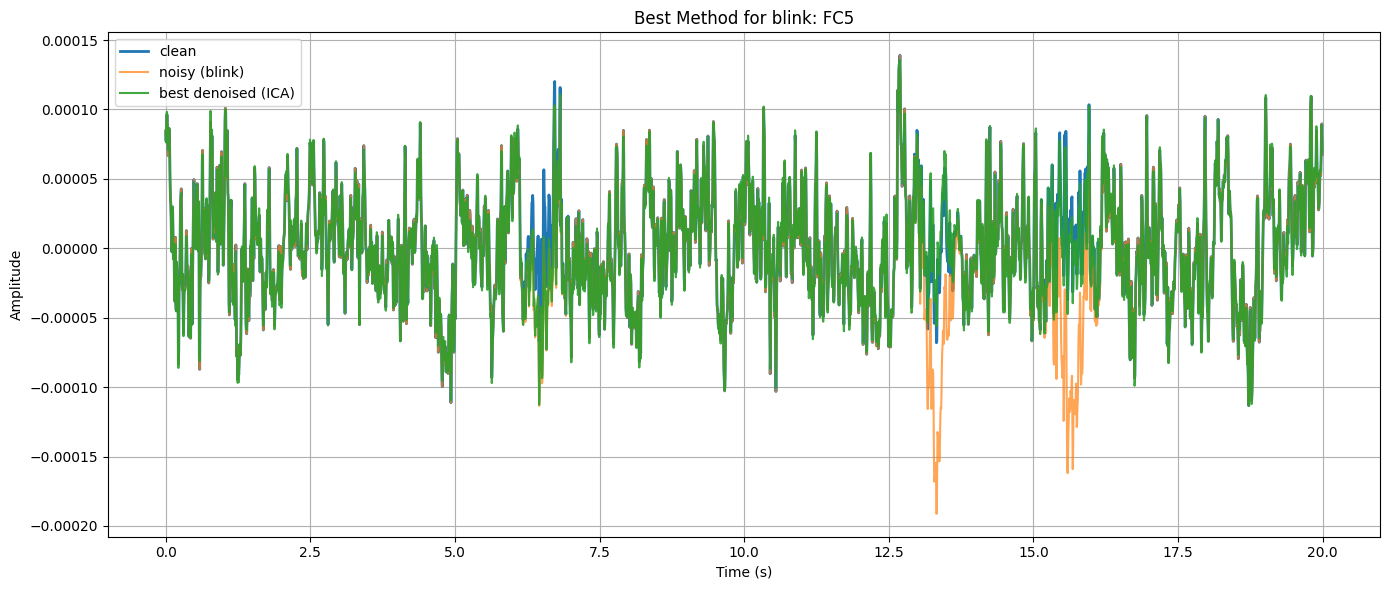

In [12]:
# This block plots the clean signal, noisy signal, and best denoised signal
# for one selected artifact type and one channel, so you can visually inspect the result.

artifact_to_plot = "blink"
channel_name = ch_names[0]
idx = ch_names.index(channel_name)
times = raw_clean.times

# Regenerate that artifact once for plotting
results_df_plot, noisy_data_plot, artifact_data_plot, artifact_log_plot = run_sweeps_for_one_artifact(
    clean_data=clean_data,
    raw_clean=raw_clean,
    sfreq=sfreq,
    ch_names=ch_names,
    rng=np.random.default_rng(12345),
    artifact_type=artifact_to_plot
)

best_row = results_df_plot.iloc[0]
best_method = best_row["method"]

if best_method == "Butterworth+Notch":
    best_output = butterworth_notch_denoise(
        noisy_data_plot,
        sfreq=sfreq,
        l_freq=float(best_row["l_freq"]),
        h_freq=float(best_row["h_freq"]),
        notch_freq=60.0,
        q=float(best_row["q"]),
        order=int(best_row["order"])
    )
elif best_method == "Wiener":
    best_output = wiener_denoise(noisy_data_plot, mysize=int(best_row["mysize"]))
elif best_method == "Wavelet":
    best_output = wavelet_denoise(
        noisy_data_plot,
        wavelet=str(best_row["wavelet"]),
        level=int(best_row["level"]),
        threshold_scale=float(best_row["threshold_scale"]),
        mode=str(best_row["mode"])
    )
elif best_method == "ICA":
    raw_noisy_plot = raw_clean.copy()
    raw_noisy_plot._data = noisy_data_plot
    best_output, _ = ica_denoise_with_artifact_reference(
        raw_noisy=raw_noisy_plot,
        artifact_data=artifact_data_plot,
        n_components=int(best_row["n_components"]),
        top_k=int(best_row["top_k"]),
        random_state=97
    )

plt.figure(figsize=(14, 6))
plt.plot(times, clean_data[idx], label="clean", linewidth=2)
plt.plot(times, noisy_data_plot[idx], label=f"noisy ({artifact_to_plot})", alpha=0.7)
plt.plot(times, best_output[idx], label=f"best denoised ({best_method})", alpha=0.9)

plt.title(f"Best Method for {artifact_to_plot}: {channel_name}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out

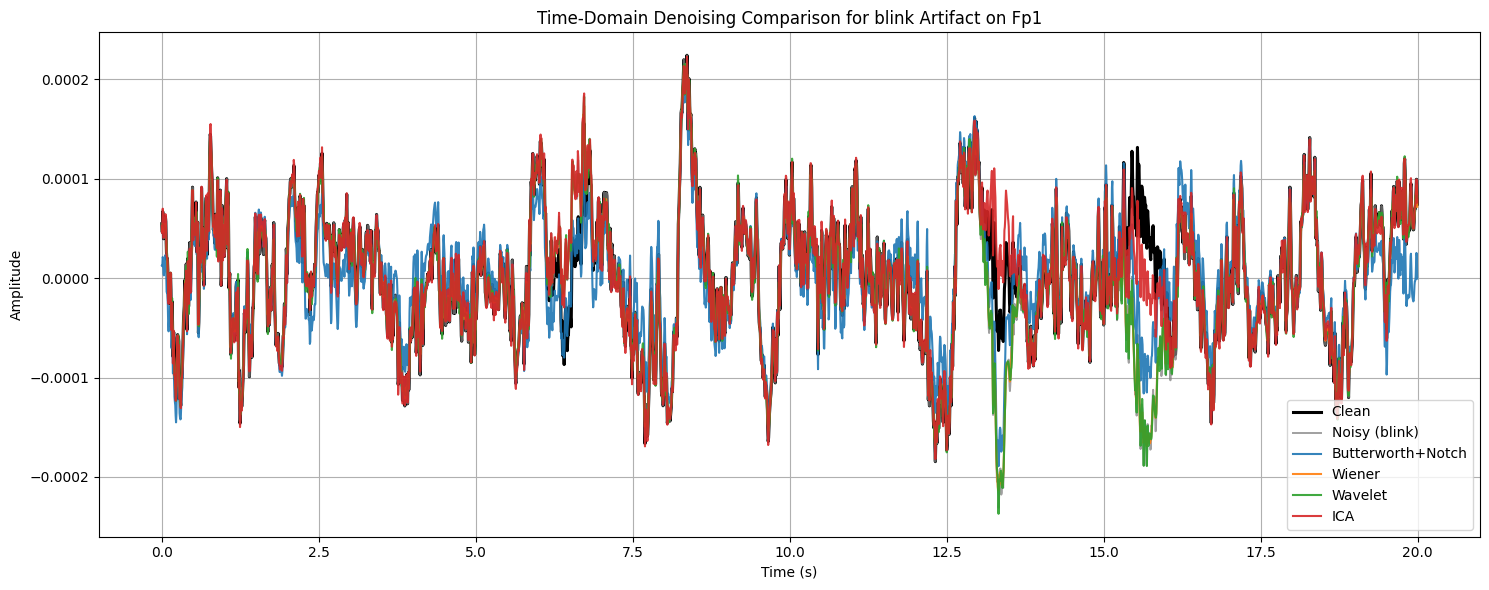

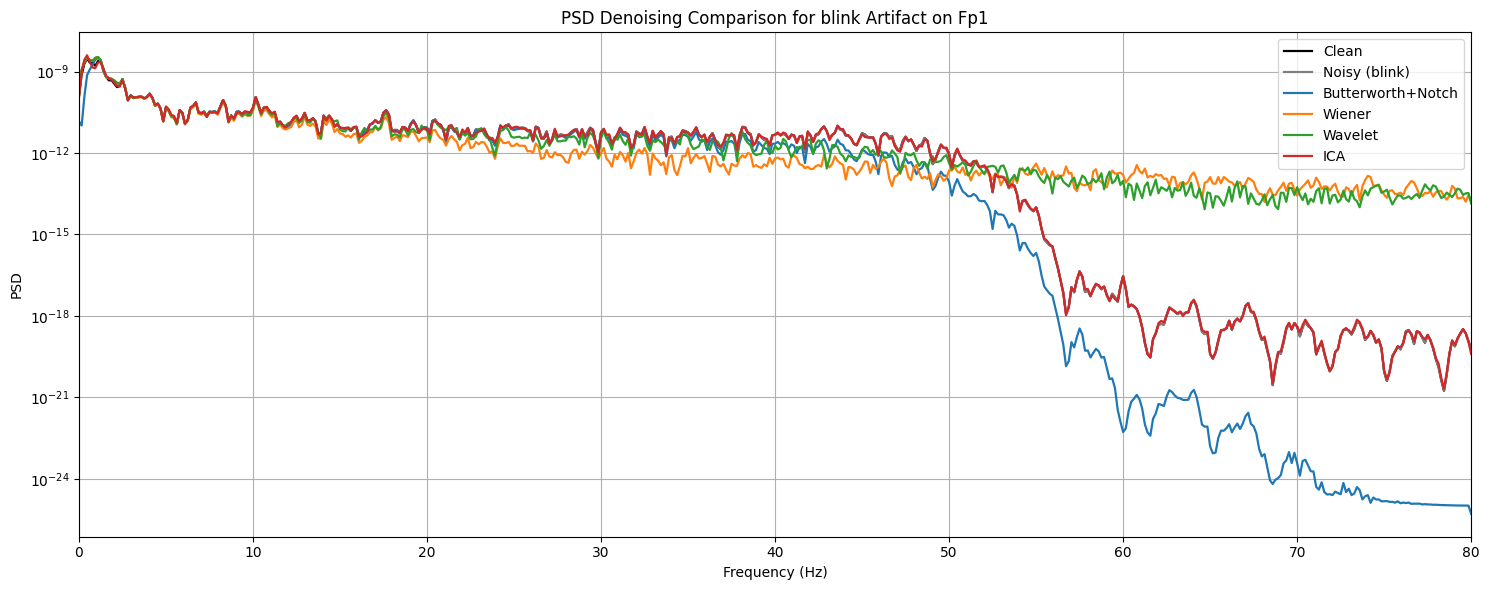

In [13]:
# This block compares all four denoising methods side-by-side for the same artifact type.
# It regenerates the noisy signal with a fixed seed, applies each method's best parameters,
# then plots time-domain and PSD comparisons for channel Fp1.

artifact_to_plot = "blink"
channel_name = "Fp1" if "Fp1" in ch_names else ch_names[0]
idx = ch_names.index(channel_name)
times = raw_clean.times

# Regenerate the same noisy signal for this artifact using a fixed seed.
results_df_plot, noisy_data_plot, artifact_data_plot, artifact_log_plot = run_sweeps_for_one_artifact(
    clean_data=clean_data,
    raw_clean=raw_clean,
    sfreq=sfreq,
    ch_names=ch_names,
    rng=np.random.default_rng(12345),
    artifact_type=artifact_to_plot
)

method_order = ["Butterworth+Notch", "Wiener", "Wavelet", "ICA"]
method_colors = {
    "clean": "black",
    "noisy": "gray",
    "Butterworth+Notch": "tab:blue",
    "Wiener": "tab:orange",
    "Wavelet": "tab:green",
    "ICA": "tab:red",
}

def apply_best_method_for_plot(method_name, results_df_plot, noisy_data_plot, artifact_data_plot):
    method_rows = results_df_plot[results_df_plot["method"] == method_name]
    if method_rows.empty:
        raise ValueError(f"No results found for method: {method_name}")

    best_row = method_rows.iloc[0]

    if method_name == "Butterworth+Notch":
        return butterworth_notch_denoise(
            noisy_data_plot,
            sfreq=sfreq,
            l_freq=float(best_row["l_freq"]),
            h_freq=float(best_row["h_freq"]),
            notch_freq=60.0,
            q=float(best_row["q"]),
            order=int(best_row["order"])
        )

    if method_name == "Wiener":
        return wiener_denoise(
            noisy_data_plot,
            mysize=int(best_row["mysize"])
        )

    if method_name == "Wavelet":
        return wavelet_denoise(
            noisy_data_plot,
            wavelet=str(best_row["wavelet"]),
            level=int(best_row["level"]),
            threshold_scale=float(best_row["threshold_scale"]),
            mode=str(best_row["mode"])
        )

    if method_name == "ICA":
        raw_noisy_plot = raw_clean.copy()
        raw_noisy_plot._data = noisy_data_plot.copy()
        denoised, _ = ica_denoise_with_artifact_reference(
            raw_noisy=raw_noisy_plot,
            artifact_data=artifact_data_plot,
            n_components=int(best_row["n_components"]),
            top_k=int(best_row["top_k"]),
            random_state=97
        )
        return denoised

    raise ValueError(f"Unknown method: {method_name}")

denoised_by_method = {
    method_name: apply_best_method_for_plot(
        method_name=method_name,
        results_df_plot=results_df_plot,
        noisy_data_plot=noisy_data_plot,
        artifact_data_plot=artifact_data_plot
    )
    for method_name in method_order
}

# Time-domain comparison on Fp1.
plt.figure(figsize=(15, 6))
plt.plot(times, clean_data[idx], label="Clean", linewidth=2.2, color=method_colors["clean"])
plt.plot(times, noisy_data_plot[idx], label=f"Noisy ({artifact_to_plot})", linewidth=1.4, alpha=0.75, color=method_colors["noisy"])

for method_name in method_order:
    plt.plot(
        times,
        denoised_by_method[method_name][idx],
        label=method_name,
        linewidth=1.5,
        alpha=0.9,
        color=method_colors[method_name]
    )

plt.title(f"Time-Domain Denoising Comparison for {artifact_to_plot} Artifact on {channel_name}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# PSD comparison on Fp1 using Welch's method.
plt.figure(figsize=(15, 6))
psd_signals = {
    "Clean": clean_data[idx],
    f"Noisy ({artifact_to_plot})": noisy_data_plot[idx],
    **{method_name: denoised_by_method[method_name][idx] for method_name in method_order}
}

psd_colors = {
    "Clean": method_colors["clean"],
    f"Noisy ({artifact_to_plot})": method_colors["noisy"],
    **{method_name: method_colors[method_name] for method_name in method_order}
}

for label, signal_1d in psd_signals.items():
    freqs, psd = signal.welch(signal_1d, fs=sfreq, nperseg=min(1024, len(signal_1d)))
    freq_mask = (freqs >= 0) & (freqs <= 80)
    plt.semilogy(freqs[freq_mask], psd[freq_mask], label=label, linewidth=1.6, color=psd_colors[label])

plt.title(f"PSD Denoising Comparison for {artifact_to_plot} Artifact on {channel_name}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.xlim(0, 80)
plt.grid(True, which="both")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## Artifact Severity Sweeps

Second experiment to test how much noise severity affects the filters. Tests robustness of the filters

Severity Scale Helper

In [14]:
# This block defines severity levels for synthetic artifacts.
# Use these multipliers to make each artifact low, medium, or high severity.

SEVERITY_SCALE = {
    "low": 0.5,
    "medium": 1.0,
    "high": 1.75,
}

## Artifact Generator w/ Severity

Uses prev artifact generator and includes the ability to change severity to scale variables

In [15]:
# This block adds a severity argument to each artifact generator.
# Severity controls the artifact amplitude while keeping the same basic artifact shape.

def add_line_noise_severity(data, sfreq, rng, severity="medium", freq=60.0):
    scale = SEVERITY_SCALE[severity]
    amp_range = (0.05 * scale, 0.3 * scale)
    return add_line_noise(data, sfreq, rng, amp_scale_range=amp_range, freq=freq)

def add_baseline_drift_severity(data, sfreq, rng, severity="medium"):
    scale = SEVERITY_SCALE[severity]
    amp_range = (0.1 * scale, 0.5 * scale)
    return add_baseline_drift(data, sfreq, rng, amp_scale_range=amp_range)

def add_blink_artifact_severity(data, sfreq, ch_names, rng, severity="medium"):
    scale = SEVERITY_SCALE[severity]
    amp_range = (1.0 * scale, 4.0 * scale)
    return add_blink_artifact(data, sfreq, ch_names, rng, amp_scale_range=amp_range)

def add_emg_like_noise_severity(data, sfreq, rng, severity="medium"):
    scale = SEVERITY_SCALE[severity]
    amp_range = (0.05 * scale, 0.35 * scale)
    return add_emg_like_noise(data, sfreq, rng, amp_scale_range=amp_range)

def add_eye_movement_artifact_severity(data, sfreq, ch_names, rng, severity="medium"):
    scale = SEVERITY_SCALE[severity]
    amp_range = (0.8 * scale, 3.0 * scale)
    return add_eye_movement_artifact(data, sfreq, ch_names, rng, amp_scale_range=amp_range)

def add_motion_artifact_severity(data, sfreq, rng, severity="medium"):
    scale = SEVERITY_SCALE[severity]
    amp_range = (0.2 * scale, 1.0 * scale)
    return add_motion_artifact(data, sfreq, rng, amp_scale_range=amp_range)

## Mixed Artifact Sample

Random artifacts combined with random severity for more complex test on filters

In [16]:
# This block creates a mixed-artifact sample at a chosen severity level.
# All selected artifact amplitudes are scaled together using the severity setting.

def add_random_artifact_mix_severity(data, sfreq, ch_names, rng, severity="medium"):
    x = data.copy()
    artifact_total = np.zeros_like(data)
    logs = []

    artifact_choices = ["line", "blink", "eye_movement", "emg", "drift", "motion"]
    n_types = int(rng.integers(2, len(artifact_choices) + 1))
    selected = rng.choice(artifact_choices, size=n_types, replace=False)

    for choice in selected:
        if choice == "line":
            x, a, log = add_line_noise_severity(x, sfreq, rng, severity=severity)
        elif choice == "blink":
            x, a, log = add_blink_artifact_severity(x, sfreq, ch_names, rng, severity=severity)
        elif choice == "eye_movement":
            x, a, log = add_eye_movement_artifact_severity(x, sfreq, ch_names, rng, severity=severity)
        elif choice == "emg":
            x, a, log = add_emg_like_noise_severity(x, sfreq, rng, severity=severity)
        elif choice == "drift":
            x, a, log = add_baseline_drift_severity(x, sfreq, rng, severity=severity)
        elif choice == "motion":
            x, a, log = add_motion_artifact_severity(x, sfreq, rng, severity=severity)

        artifact_total += a
        logs.append(log)

    return x, artifact_total, logs

Run Artifact Generation

In [17]:
# This block chooses which single artifact (or mixed artifact condition) to generate
# at the requested severity level.

def generate_noisy_sample_with_severity(clean_data, sfreq, ch_names, rng, artifact_type, severity="medium"):
    if artifact_type == "line":
        return add_line_noise_severity(clean_data, sfreq, rng, severity=severity)
    elif artifact_type == "blink":
        return add_blink_artifact_severity(clean_data, sfreq, ch_names, rng, severity=severity)
    elif artifact_type == "drift":
        return add_baseline_drift_severity(clean_data, sfreq, rng, severity=severity)
    elif artifact_type == "emg":
        return add_emg_like_noise_severity(clean_data, sfreq, rng, severity=severity)
    elif artifact_type == "eye_movement":
        return add_eye_movement_artifact_severity(clean_data, sfreq, ch_names, rng, severity=severity)
    elif artifact_type == "motion":
        return add_motion_artifact_severity(clean_data, sfreq, rng, severity=severity)
    elif artifact_type == "mixed":
        return add_random_artifact_mix_severity(clean_data, sfreq, ch_names, rng, severity=severity)
    else:
        raise ValueError(f"Unknown artifact_type: {artifact_type}")

## Parameter Sweeps

Same as prev but now including a test for each severity. Takes super long to run :(

This one is for 1 chosen artifact

In [18]:
# This block runs the full denoising parameter sweeps for one artifact type
# at one chosen severity level.

def run_sweeps_for_one_artifact_and_severity(clean_data, raw_clean, sfreq, ch_names, rng, artifact_type, severity):
    noisy_out = generate_noisy_sample_with_severity(
        clean_data=clean_data,
        sfreq=sfreq,
        ch_names=ch_names,
        rng=rng,
        artifact_type=artifact_type,
        severity=severity
    )

    noisy_data, artifact_data, artifact_log = noisy_out

    raw_noisy = mne.io.RawArray(noisy_data.copy(), raw_clean.info.copy(), verbose=False)

    rows = []

    # Butterworth + notch sweep
    for l_freq in [0.5, 1.0, 2.0]:
        for h_freq in [30.0, 40.0, 45.0]:
            if l_freq >= h_freq:
                continue
            for order in [2, 4, 6]:
                for q in [20.0, 30.0, 40.0]:
                    denoised = butterworth_notch_denoise(
                        noisy_data, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq,
                        notch_freq=60.0, q=q, order=order
                    )
                    metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
                    rows.append({
                        "artifact_type": artifact_type,
                        "severity": severity,
                        "method": "Butterworth+Notch",
                        "l_freq": l_freq,
                        "h_freq": h_freq,
                        "order": order,
                        "q": q,
                        "mysize": np.nan,
                        "wavelet": np.nan,
                        "level": np.nan,
                        "threshold_scale": np.nan,
                        "mode": np.nan,
                        "n_components": np.nan,
                        "top_k": np.nan,
                        "excluded_components": np.nan,
                        "converged": np.nan,
                        **metrics
                    })

    # Wiener sweep
    for mysize in [5, 9, 15, 21, 31]:
        denoised = wiener_denoise(noisy_data, mysize=mysize)
        metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
        rows.append({
            "artifact_type": artifact_type,
            "severity": severity,
            "method": "Wiener",
            "l_freq": np.nan,
            "h_freq": np.nan,
            "order": np.nan,
            "q": np.nan,
            "mysize": mysize,
            "wavelet": np.nan,
            "level": np.nan,
            "threshold_scale": np.nan,
            "mode": np.nan,
            "n_components": np.nan,
            "top_k": np.nan,
            "excluded_components": np.nan,
            "converged": np.nan,
            **metrics
        })

    # Wavelet sweep
    if HAS_PYWT:
        for wavelet_name in ["db4", "sym4", "coif3"]:
            for level in [3, 4, 5]:
                for threshold_scale in [0.8, 1.0, 1.2, 1.5]:
                    for mode in ["soft", "hard"]:
                        denoised = wavelet_denoise(
                            noisy_data,
                            wavelet=wavelet_name,
                            level=level,
                            threshold_scale=threshold_scale,
                            mode=mode
                        )
                        metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
                        rows.append({
                            "artifact_type": artifact_type,
                            "severity": severity,
                            "method": "Wavelet",
                            "l_freq": np.nan,
                            "h_freq": np.nan,
                            "order": np.nan,
                            "q": np.nan,
                            "mysize": np.nan,
                            "wavelet": wavelet_name,
                            "level": level,
                            "threshold_scale": threshold_scale,
                            "mode": mode,
                            "n_components": np.nan,
                            "top_k": np.nan,
                            "excluded_components": np.nan,
                            "converged": np.nan,
                            **metrics
                        })

    # ICA sweep
    for n_components in [10, 15, 20, 30]:
        for top_k in [1, 2, 3, 4]:
            denoised, info = ica_denoise_with_artifact_reference(
                raw_noisy=raw_noisy,
                artifact_data=artifact_data,
                n_components=n_components,
                top_k=top_k,
                random_state=97
            )
            metrics = evaluate_method(clean_data, noisy_data, denoised, sfreq)
            rows.append({
                "artifact_type": artifact_type,
                "severity": severity,
                "method": "ICA",
                "l_freq": np.nan,
                "h_freq": np.nan,
                "order": np.nan,
                "q": np.nan,
                "mysize": np.nan,
                "wavelet": np.nan,
                "level": np.nan,
                "threshold_scale": np.nan,
                "mode": np.nan,
                "n_components": n_components,
                "top_k": top_k,
                "excluded_components": str(info["excluded_components"]),
                "converged": info["converged"],
                **metrics
            })

    results_df = pd.DataFrame(rows)

    # Keep only converged ICA rows
    ica_mask = (results_df["method"] == "ICA")
    results_df = pd.concat([
        results_df[~ica_mask],
        results_df[ica_mask & (results_df["converged"] == True)]
    ], axis=0).reset_index(drop=True)

    results_df = add_combined_score(results_df)

    return results_df, noisy_data, artifact_data, artifact_log

All Artifact Parameter Sweep

In [19]:
# This block runs the full experiment across:
# - multiple artifact types
# - multiple severity levels
# For each artifact and severity, it runs all denoising method sweeps and stores the results.

artifact_types_to_test = ["line", "blink", "drift", "emg", "eye_movement", "motion", "mixed"]
severity_levels_to_test = ["low", "medium", "high"]

all_artifact_severity_results = {}
all_artifact_severity_best_per_method = {}

clean_data = raw_clean.get_data()

for artifact_type in artifact_types_to_test:
    for severity in severity_levels_to_test:
        print(f"Running sweeps for artifact={artifact_type}, severity={severity}")

        results_df, noisy_data_art, artifact_data_art, artifact_log_art = run_sweeps_for_one_artifact_and_severity(
            clean_data=clean_data,
            raw_clean=raw_clean,
            sfreq=sfreq,
            ch_names=ch_names,
            rng=rng,
            artifact_type=artifact_type,
            severity=severity
        )

        all_artifact_severity_results[(artifact_type, severity)] = results_df

        best_rows = []
        for method_name in results_df["method"].unique():
            best_rows.append(results_df[results_df["method"] == method_name].iloc[0])

        best_per_method_df = pd.DataFrame(best_rows).reset_index(drop=True)
        best_per_method_df = add_combined_score(best_per_method_df)

        all_artifact_severity_best_per_method[(artifact_type, severity)] = best_per_method_df

Running sweeps for artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transformi

## Summary Table

Shows Quantitative data and results from the experiment. Accounts for all artifact types and 3 levels of severity but only single subject.

In [20]:
# This block creates the main summary table.
# For each artifact type and severity level, it shows the best overall denoising method and its best parameters.

summary_rows = []

for (artifact_type, severity), best_df in all_artifact_severity_best_per_method.items():
    best_row = best_df.iloc[0].copy()
    summary_rows.append(best_row)

artifact_severity_summary_table = pd.DataFrame(summary_rows).reset_index(drop=True)

artifact_severity_summary_table = artifact_severity_summary_table[
    [
        "artifact_type",
        "severity",
        "method",
        "mse",
        "corr",
        "snr_before_db",
        "snr_after_db",
        "snr_improvement_db",
        "mean_band_rel_error",
        "combined_score",
        "l_freq",
        "h_freq",
        "order",
        "q",
        "mysize",
        "wavelet",
        "level",
        "threshold_scale",
        "mode",
        "n_components",
        "top_k",
        "excluded_components",
        "converged"
    ]
]

artifact_severity_summary_table

,artifact_type,severity,method,mse,corr,snr_before_db,snr_after_db,snr_improvement_db,mean_band_rel_error,combined_score,...,q,mysize,wavelet,level,threshold_scale,mode,n_components,top_k,excluded_components,converged
0,line,low,Wavelet,8.005590e-11,0.981179,22.795200,14.231595,-8.563605,0.046215,0.986596,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
1,line,medium,ICA,3.362788e-12,0.999217,17.458499,26.921801,9.463302,0.002130,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,30.0,2.0,"[np.int64(27), np.int64(24)]",True
2,line,high,ICA,6.530564e-12,0.998478,12.907321,24.551166,11.643846,0.002558,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,2.0,"[np.int64(8), np.int64(9)]",True
3,blink,low,ICA,1.136851e-11,0.997355,15.421146,22.396267,6.975121,0.000924,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,15.0,1.0,[np.int64(13)],True
4,blink,medium,ICA,1.207722e-10,0.972152,9.074103,12.463959,3.389856,0.022587,0.988287,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,3.0,"[np.int64(9), np.int64(8), np.int64(7)]",True
5,blink,high,ICA,1.746583e-11,0.996008,2.856729,20.655754,17.799024,0.002046,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,30.0,2.0,"[np.int64(1), np.int64(10)]",True
6,drift,low,Wavelet,8.535558e-11,0.980005,18.904221,13.956537,-4.947684,0.030637,1.000000,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
7,drift,medium,ICA,1.457998e-10,0.966753,12.687189,11.652188,-1.035001,0.009938,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,[np.int64(9)],True
8,drift,high,Butterworth+Notch,2.067893e-10,0.951333,7.516893,10.143209,2.626316,0.033370,1.000000,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,emg,low,Wavelet,6.041539e-11,0.985830,28.893995,15.436669,-13.457326,0.030501,1.000000,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN


Results - Summary Table & Plots

In [21]:
# This block makes the final summary easier to read by collapsing hyperparameters
# into one params column instead of many NaN-filled columns.

def summarize_params(row):
    method = row["method"]

    if method == "Butterworth+Notch":
        return f"l={row['l_freq']}, h={row['h_freq']}, order={int(row['order'])}, q={row['q']}"
    elif method == "Wiener":
        return f"mysize={int(row['mysize'])}"
    elif method == "Wavelet":
        return f"wavelet={row['wavelet']}, level={int(row['level'])}, thresh={row['threshold_scale']}, mode={row['mode']}"
    elif method == "ICA":
        return f"n_components={int(row['n_components'])}, top_k={int(row['top_k'])}, excluded={row['excluded_components']}"
    else:
        return ""

artifact_severity_summary_display = artifact_severity_summary_table.copy()
artifact_severity_summary_display["params"] = artifact_severity_summary_display.apply(summarize_params, axis=1)

artifact_severity_summary_display = artifact_severity_summary_display[
    [
        "artifact_type",
        "severity",
        "method",
        "params",
        "mse",
        "corr",
        "snr_after_db",
        "snr_improvement_db",
        "mean_band_rel_error",
        "combined_score"
    ]
]

artifact_severity_summary_display = artifact_severity_summary_display.sort_values(
    by=["artifact_type", "severity"]
).reset_index(drop=True)

artifact_severity_summary_display

,artifact_type,severity,method,params,mse,corr,snr_after_db,snr_improvement_db,mean_band_rel_error,combined_score
0,blink,high,ICA,"n_components=30, top_k=2, excluded=[np.int64(1...",1.746583e-11,0.996008,20.655754,17.799024,0.002046,1.000000
1,blink,low,ICA,"n_components=15, top_k=1, excluded=[np.int64(13)]",1.136851e-11,0.997355,22.396267,6.975121,0.000924,1.000000
2,blink,medium,ICA,"n_components=10, top_k=3, excluded=[np.int64(9...",1.207722e-10,0.972152,12.463959,3.389856,0.022587,0.988287
3,drift,high,Butterworth+Notch,"l=0.5, h=45.0, order=2, q=40.0",2.067893e-10,0.951333,10.143209,2.626316,0.033370,1.000000
4,drift,low,Wavelet,"wavelet=coif3, level=3, thresh=0.8, mode=hard",8.535558e-11,0.980005,13.956537,-4.947684,0.030637,1.000000
5,drift,medium,ICA,"n_components=10, top_k=1, excluded=[np.int64(9)]",1.457998e-10,0.966753,11.652188,-1.035001,0.009938,1.000000
6,emg,high,ICA,"n_components=30, top_k=1, excluded=[np.int64(29)]",2.498687e-11,0.994181,19.171901,-0.828271,0.005955,1.000000
7,emg,low,Wavelet,"wavelet=coif3, level=3, thresh=0.8, mode=hard",6.041539e-11,0.985830,15.436669,-13.457326,0.030501,1.000000
8,emg,medium,ICA,"n_components=30, top_k=1, excluded=[np.int64(29)]",1.439123e-11,0.996649,21.446707,-2.608801,0.003125,1.000000
9,eye_movement,high,ICA,"n_components=10, top_k=2, excluded=[np.int64(5...",6.924399e-11,0.983933,14.853349,7.065106,0.017357,1.000000


In [22]:
# This block lets you inspect one artifact type across low/medium/high severity
# to see how the winning method changes as the artifact gets stronger.

artifact_of_interest = "blink"

artifact_severity_summary_display[
    artifact_severity_summary_display["artifact_type"] == artifact_of_interest
].reset_index(drop=True)

,artifact_type,severity,method,params,mse,corr,snr_after_db,snr_improvement_db,mean_band_rel_error,combined_score
0,blink,high,ICA,"n_components=30, top_k=2, excluded=[np.int64(1...",1.746583e-11,0.996008,20.655754,17.799024,0.002046,1.000000
1,blink,low,ICA,"n_components=15, top_k=1, excluded=[np.int64(13)]",1.136851e-11,0.997355,22.396267,6.975121,0.000924,1.000000
2,blink,medium,ICA,"n_components=10, top_k=3, excluded=[np.int64(9...",1.207722e-10,0.972152,12.463959,3.389856,0.022587,0.988287


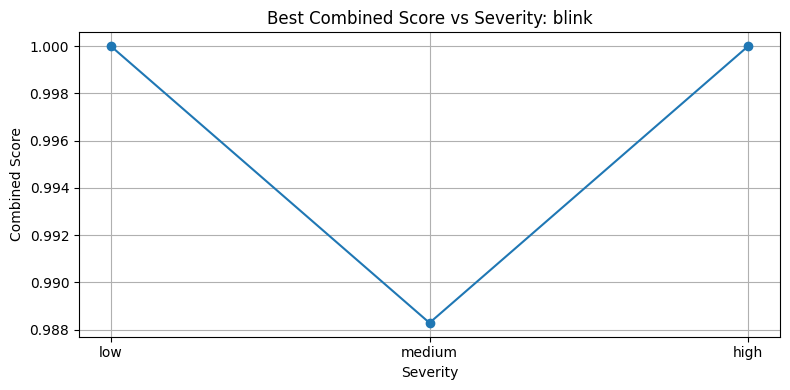

,severity,method,params,combined_score,snr_improvement_db,mean_band_rel_error
1,low,ICA,"n_components=15, top_k=1, excluded=[np.int64(13)]",1.000000,6.975121,0.000924
2,medium,ICA,"n_components=10, top_k=3, excluded=[np.int64(9...",0.988287,3.389856,0.022587
0,high,ICA,"n_components=30, top_k=2, excluded=[np.int64(1...",1.000000,17.799024,0.002046


In [23]:
# This block plots combined_score versus severity for the winning method of one artifact type.

artifact_of_interest = "blink"
plot_df = artifact_severity_summary_display[
    artifact_severity_summary_display["artifact_type"] == artifact_of_interest
].copy()

severity_order = {"low": 0, "medium": 1, "high": 2}
plot_df["severity_order"] = plot_df["severity"].map(severity_order)
plot_df = plot_df.sort_values("severity_order")

plt.figure(figsize=(8, 4))
plt.plot(plot_df["severity"], plot_df["combined_score"], marker="o")
plt.title(f"Best Combined Score vs Severity: {artifact_of_interest}")
plt.xlabel("Severity")
plt.ylabel("Combined Score")
plt.grid(True)
plt.tight_layout()
plt.show()

plot_df[["severity", "method", "params", "combined_score", "snr_improvement_db", "mean_band_rel_error"]]

In [24]:
# This block measures how far ahead the winning method is for each artifact/severity
# by comparing the best and second-best combined scores.

gap_rows = []

for key, best_df in all_artifact_severity_best_per_method.items():
    artifact_type, severity = key
    if len(best_df) >= 2:
        best_row = best_df.iloc[0]
        second_row = best_df.iloc[1]

        gap_rows.append({
            "artifact_type": artifact_type,
            "severity": severity,
            "best_method": best_row["method"],
            "runner_up_method": second_row["method"],
            "best_score": best_row["combined_score"],
            "runner_up_score": second_row["combined_score"],
            "score_gap": best_row["combined_score"] - second_row["combined_score"],
            "best_snr_after_db": best_row["snr_after_db"],
            "runner_up_snr_after_db": second_row["snr_after_db"],
            "snr_after_gap_db": best_row["snr_after_db"] - second_row["snr_after_db"],
            "best_mse": best_row["mse"],
            "runner_up_mse": second_row["mse"],
            "mse_gap": second_row["mse"] - best_row["mse"],
        })

gap_table = pd.DataFrame(gap_rows).sort_values(
    by=["artifact_type", "severity"]
).reset_index(drop=True)

gap_table

,artifact_type,severity,best_method,runner_up_method,best_score,runner_up_score,score_gap,best_snr_after_db,runner_up_snr_after_db,snr_after_gap_db,best_mse,runner_up_mse,mse_gap
0,blink,high,ICA,Butterworth+Notch,1.000000,0.530255,0.469745,20.655754,6.730963,13.924791,1.746583e-11,4.548771e-10,4.374113e-10
1,blink,low,ICA,Wavelet,1.000000,0.444179,0.555821,22.396267,12.514956,9.881311,1.136851e-11,1.193507e-10,1.079822e-10
2,blink,medium,ICA,Butterworth+Notch,0.988287,0.398125,0.590162,12.463959,8.650623,3.813336,1.207722e-10,2.920096e-10,1.712374e-10
3,drift,high,Butterworth+Notch,Wavelet,1.000000,0.498837,0.501163,10.143209,6.893610,3.249598,2.067893e-10,4.381199e-10,2.313305e-10
4,drift,low,Wavelet,Wiener,1.000000,0.480373,0.519627,13.956537,12.304751,1.651787,8.535558e-11,1.253191e-10,3.996353e-11
5,drift,medium,ICA,Wavelet,1.000000,0.642461,0.357539,11.652188,10.904253,0.747935,1.457998e-10,1.733889e-10,2.758914e-11
6,emg,high,ICA,Wavelet,1.000000,0.658617,0.341383,19.171901,14.392928,4.778973,2.498687e-11,7.710005e-11,5.211318e-11
7,emg,low,Wavelet,ICA,1.000000,0.982694,0.017306,15.436669,15.312609,0.124060,6.041539e-11,6.219508e-11,1.779685e-12
8,emg,medium,ICA,Wavelet,1.000000,0.648590,0.351410,21.446707,15.097646,6.349061,1.439123e-11,6.540176e-11,5.101052e-11
9,eye_movement,high,ICA,Butterworth+Notch,1.000000,0.339168,0.660832,14.853349,7.742150,7.111200,6.924399e-11,3.601845e-10,2.909406e-10


## Multi Subject Test

Run Parameter sweep, all artifacts, and severity scale but with different subjects to validate that results do not work on only 1 subject and is not a coincedence

## Section 6: Multi-Subject Experiment
To ensure results generalize beyond a single subject, the full parameter sweep is run across 5 subjects from the EEGMMIDB dataset (subjects 1-5). For each subject, a 20-second eyes-closed baseline segment is extracted, each artifact type is injected at each severity level, all four methods are swept across their parameter grids, and the best configuration per condition is recorded. Results are aggregated across subjects and reported as mean ± standard deviation.

In [25]:
# This block loads one EEGMMIDB subject, preprocesses the baseline runs,
# and extracts one clean segment to use for synthetic artifact testing.

def load_clean_segment_for_subject(subject_id, runs=[2], segment_seconds=20, random_seed=123):  # Use only the eyes-closed run to minimize natural blink artifacts in the pseudo-clean reference signal.
    local_rng = np.random.default_rng(random_seed + subject_id)

    file_paths = eegbci.load_data(subject_id, runs)
    raw_list = [mne.io.read_raw_edf(fp, preload=True, verbose=False) for fp in file_paths]

    raw = mne.concatenate_raws(raw_list)
    eegbci.standardize(raw)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")

    raw.pick_types(eeg=True)
    raw_clean_full = raw.copy().filter(l_freq=0.5, h_freq=45.0, verbose=False)

    sfreq_local = raw_clean_full.info["sfreq"]
    segment_samples = int(segment_seconds * sfreq_local)

    n_total = raw_clean_full.n_times
    if segment_samples > n_total:
        raise ValueError(f"Segment too long for subject {subject_id}")

    start_max = n_total - segment_samples
    start_sample = int(local_rng.integers(0, start_max + 1))
    stop_sample = start_sample + segment_samples

    raw_clean_local = raw_clean_full.copy().crop(
        tmin=start_sample / sfreq_local,
        tmax=(stop_sample - 1) / sfreq_local
    )

    clean_data_local = raw_clean_local.get_data()
    ch_names_local = raw_clean_local.ch_names

    return raw_clean_local, clean_data_local, ch_names_local, sfreq_local

In [26]:
# This block runs the artifact-by-artifact severity sweep for one subject.

def run_full_experiment_for_subject(subject_id, artifact_types, severity_levels, rng_seed=123):
    raw_clean_local, clean_data_local, ch_names_local, sfreq_local = load_clean_segment_for_subject(
        subject_id=subject_id,
        runs=[2],  # Use only the eyes-closed run to minimize natural blink artifacts in the pseudo-clean reference signal.
        segment_seconds=20,
        random_seed=rng_seed
    )

    subject_rng = np.random.default_rng(rng_seed + 1000 * subject_id)

    subject_results = []
    subject_best_rows = []

    for artifact_type in artifact_types:
        for severity in severity_levels:
            print(f"Subject {subject_id}: artifact={artifact_type}, severity={severity}")

            results_df, noisy_data_art, artifact_data_art, artifact_log_art = run_sweeps_for_one_artifact_and_severity(
                clean_data=clean_data_local,
                raw_clean=raw_clean_local,
                sfreq=sfreq_local,
                ch_names=ch_names_local,
                rng=subject_rng,
                artifact_type=artifact_type,
                severity=severity
            )

            results_df = results_df.copy()
            results_df["subject_id"] = subject_id
            subject_results.append(results_df)

            best_rows = []
            for method_name in results_df["method"].unique():
                best_rows.append(results_df[results_df["method"] == method_name].iloc[0])

            best_per_method_df = pd.DataFrame(best_rows).reset_index(drop=True)
            best_per_method_df = add_combined_score(best_per_method_df)
            best_per_method_df["subject_id"] = subject_id

            subject_best_rows.append(best_per_method_df)

    subject_results_df = pd.concat(subject_results, ignore_index=True)
    subject_best_df = pd.concat(subject_best_rows, ignore_index=True)

    return subject_results_df, subject_best_df

In [27]:
# This block runs the full experiment across multiple subjects.

subject_ids_to_test = [1, 2, 3, 4, 5]
artifact_types_to_test = ["line", "blink", "drift", "emg", "mixed"]
severity_levels_to_test = ["low", "medium", "high"]

all_subject_results = []
all_subject_best = []

for subject_id in subject_ids_to_test:
    subject_results_df, subject_best_df = run_full_experiment_for_subject(
        subject_id=subject_id,
        artifact_types=artifact_types_to_test,
        severity_levels=severity_levels_to_test,
        rng_seed=123
    )

    all_subject_results.append(subject_results_df)
    all_subject_best.append(subject_best_df)

all_subject_results_df = pd.concat(all_subject_results, ignore_index=True)
all_subject_best_df = pd.concat(all_subject_best, ignore_index=True)

print(all_subject_results_df.shape)
print(all_subject_best_df.shape)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 1: artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting bac

Download complete in 07s (1.2 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 2: artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2

Download complete in 07s (1.2 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 3: artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2

Download complete in 11s (1.2 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 4: artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2

Download complete in 12s (1.2 MB)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Subject 5: artifact=line, severity=low
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 4 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2

## Final Results - Summary Table

In [28]:
# This block finds the best overall method for each subject, artifact type, and severity level.

best_overall_rows = []

for (subject_id, artifact_type, severity), group_df in all_subject_best_df.groupby(
    ["subject_id", "artifact_type", "severity"]
):
    ranked = add_combined_score(group_df.reset_index(drop=True))
    best_row = ranked.iloc[0].copy()
    best_overall_rows.append(best_row)

multi_subject_best_table = pd.DataFrame(best_overall_rows).reset_index(drop=True)

multi_subject_best_table = multi_subject_best_table[
    [
        "subject_id",
        "artifact_type",
        "severity",
        "method",
        "mse",
        "corr",
        "snr_after_db",
        "snr_improvement_db",
        "mean_band_rel_error",
        "combined_score",
        "l_freq",
        "h_freq",
        "order",
        "q",
        "mysize",
        "wavelet",
        "level",
        "threshold_scale",
        "mode",
        "n_components",
        "top_k",
        "excluded_components",
        "converged"
    ]
]

multi_subject_best_table.head(20)

,subject_id,artifact_type,severity,method,mse,corr,snr_after_db,snr_improvement_db,mean_band_rel_error,combined_score,...,q,mysize,wavelet,level,threshold_scale,mode,n_components,top_k,excluded_components,converged
0,1,blink,high,ICA,2.688275e-11,0.995251,20.009598,3.738948,0.003100,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,15.0,1.0,[np.int64(13)],True
1,1,blink,low,ICA,4.982517e-12,0.999116,26.694115,6.760222,0.001474,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1.0,[np.int64(18)],True
2,1,blink,medium,ICA,5.570816e-11,0.990082,16.926499,4.117341,0.003060,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,30.0,1.0,[np.int64(10)],True
3,1,drift,high,Butterworth+Notch,2.134579e-10,0.961277,11.149534,2.602162,0.037545,0.976212,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,drift,low,ICA,5.864533e-11,0.989605,16.707190,-1.719926,0.007506,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1.0,[np.int64(19)],True
5,1,drift,medium,Wavelet,2.066725e-10,0.963819,11.289164,-1.197994,0.026289,0.996158,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
6,1,emg,high,Wavelet,7.973570e-11,0.985679,15.392299,-4.008337,0.019088,0.997191,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
7,1,emg,low,Wavelet,5.247621e-11,0.990566,17.181349,-11.514851,0.022821,1.000000,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
8,1,emg,medium,Wavelet,6.022047e-11,0.989170,16.593988,-7.098697,0.023111,1.000000,...,NaN,NaN,coif3,3.0,0.8,hard,NaN,NaN,NaN,NaN
9,1,line,high,ICA,3.729549e-12,0.999333,27.714758,15.385144,0.000872,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,15.0,2.0,"[np.int64(10), np.int64(9)]",True


Average Results

In [29]:
# This block aggregates results across subjects so you can report average performance.

multi_subject_summary = multi_subject_best_table.groupby(
    ["artifact_type", "severity", "method"],
    dropna=False
).agg(
    mean_mse=("mse", "mean"),
    std_mse=("mse", "std"),
    mean_corr=("corr", "mean"),
    std_corr=("corr", "std"),
    mean_snr_after_db=("snr_after_db", "mean"),
    std_snr_after_db=("snr_after_db", "std"),
    mean_snr_improvement_db=("snr_improvement_db", "mean"),
    std_snr_improvement_db=("snr_improvement_db", "std"),
    mean_band_rel_error=("mean_band_rel_error", "mean"),
    std_band_rel_error=("mean_band_rel_error", "std"),
    mean_combined_score=("combined_score", "mean"),
    std_combined_score=("combined_score", "std"),
    n_subjects=("subject_id", "nunique")
).reset_index()

multi_subject_summary = multi_subject_summary.sort_values(
    by=["artifact_type", "severity", "mean_combined_score"],
    ascending=[True, True, False]
).reset_index(drop=True)

multi_subject_summary.head(30)

,artifact_type,severity,method,mean_mse,std_mse,mean_corr,std_corr,mean_snr_after_db,std_snr_after_db,mean_snr_improvement_db,std_snr_improvement_db,mean_band_rel_error,std_band_rel_error,mean_combined_score,std_combined_score,n_subjects
0,blink,high,ICA,3.213897e-11,1.455820e-11,0.983898,0.018245,16.458932,4.097699,7.354881,4.336142,0.014028,0.016394,1.000000,2.135427e-12,4
1,blink,high,Wavelet,3.645824e-11,NaN,0.961701,NaN,11.052766,NaN,-3.318614,NaN,0.058311,NaN,0.965196,NaN,1
2,blink,low,ICA,4.766722e-12,3.051805e-13,0.997387,0.002444,23.226868,4.903429,1.840117,6.958080,0.005920,0.006287,1.000000,1.520321e-12,2
3,blink,low,Butterworth+Notch,4.017229e-11,NaN,0.975076,NaN,12.961404,NaN,-3.357853,NaN,0.021060,NaN,1.000000,NaN,1
4,blink,low,Wavelet,4.791923e-11,3.610635e-11,0.981270,0.007051,14.339347,1.755140,-10.283564,2.653670,0.043557,0.014619,0.978573,3.030295e-02,2
5,blink,medium,ICA,4.699802e-11,4.363063e-11,0.982941,0.010848,15.078880,2.497625,4.646475,1.917124,0.011517,0.005170,0.999014,1.149761e-03,5
6,drift,high,Butterworth+Notch,1.296191e-10,1.122086e-10,0.953830,0.019466,10.682396,1.903811,2.549507,1.875105,0.034801,0.018508,0.985312,1.342118e-02,5
7,drift,low,Wavelet,1.798633e-11,NaN,0.982759,NaN,14.418863,NaN,-4.715950,NaN,0.028759,NaN,1.000000,NaN,1
8,drift,low,ICA,3.544747e-11,1.812644e-11,0.986868,0.005666,15.952344,1.888897,-2.796786,1.680115,0.012225,0.010131,0.996619,6.761803e-03,4
9,drift,medium,ICA,3.045108e-11,NaN,0.971781,NaN,12.226919,NaN,-1.352941,NaN,0.017153,NaN,1.000000,NaN,1


## Section 7: Results — Best Method Per Condition
The table above shows the best performing method for each subject, artifact type, and severity combination based on the combined score. Key observations:
- ICA dominates for line noise and blink artifacts across all severity levels — these are spatially and spectrally structured artifacts that ICA's source separation handles well
- Butterworth+Notch takes over for drift at medium and high severity — baseline drift is a slow sub-Hz phenomenon that a highpass filter removes cleanly without needing complex decomposition
- Wavelet wins for EMG at medium and high severity — EMG is broadband high-frequency noise that wavelet's multiresolution decomposition can localize and threshold effectively
- Mixed artifacts show more variability since no single method handles all artifact types simultaneously

In [30]:
# This block counts how often each method is the winner across subjects
# for each artifact type and severity level.

winner_counts = multi_subject_best_table.groupby(
    ["artifact_type", "severity", "method"]
).size().reset_index(name="win_count")

winner_counts = winner_counts.sort_values(
    by=["artifact_type", "severity", "win_count"],
    ascending=[True, True, False]
).reset_index(drop=True)

winner_counts

,artifact_type,severity,method,win_count
0,blink,high,ICA,4
1,blink,high,Wavelet,1
2,blink,low,ICA,2
3,blink,low,Wavelet,2
4,blink,low,Butterworth+Notch,1
5,blink,medium,ICA,5
6,drift,high,Butterworth+Notch,5
7,drift,low,ICA,4
8,drift,low,Wavelet,1
9,drift,medium,Butterworth+Notch,2


## Section 8: Results — Winner Counts and Visualization
The winner_counts table summarizes how many subjects each method won for each artifact type and severity combination (out of 5 subjects). The heatmap below visualizes this as a color-coded grid making the dominant method immediately apparent. ICA (red) dominates most cells, with Butterworth+Notch (blue) taking drift artifacts and Wavelet (green) taking EMG at higher severities. Wiener filter never achieves dominance in any condition.

In [2]:
# Load pre-saved results from CSV so visualization cells can run independently.

import pandas as pd
from pathlib import Path

all_subject_best_df    = pd.read_csv("all_subject_best_df.csv")
print(f"Loaded all_subject_best_df    : {all_subject_best_df.shape[0]} rows, {all_subject_best_df.shape[1]} cols")

multi_subject_summary  = pd.read_csv("multi_subject_summary.csv")
print(f"Loaded multi_subject_summary  : {multi_subject_summary.shape[0]} rows, {multi_subject_summary.shape[1]} cols")

winner_counts          = pd.read_csv("winner_counts.csv")
print(f"Loaded winner_counts          : {winner_counts.shape[0]} rows, {winner_counts.shape[1]} cols")


Loaded all_subject_best_df    : 292 rows, 28 cols
Loaded multi_subject_summary  : 29 rows, 16 cols
Loaded winner_counts          : 29 rows, 4 cols


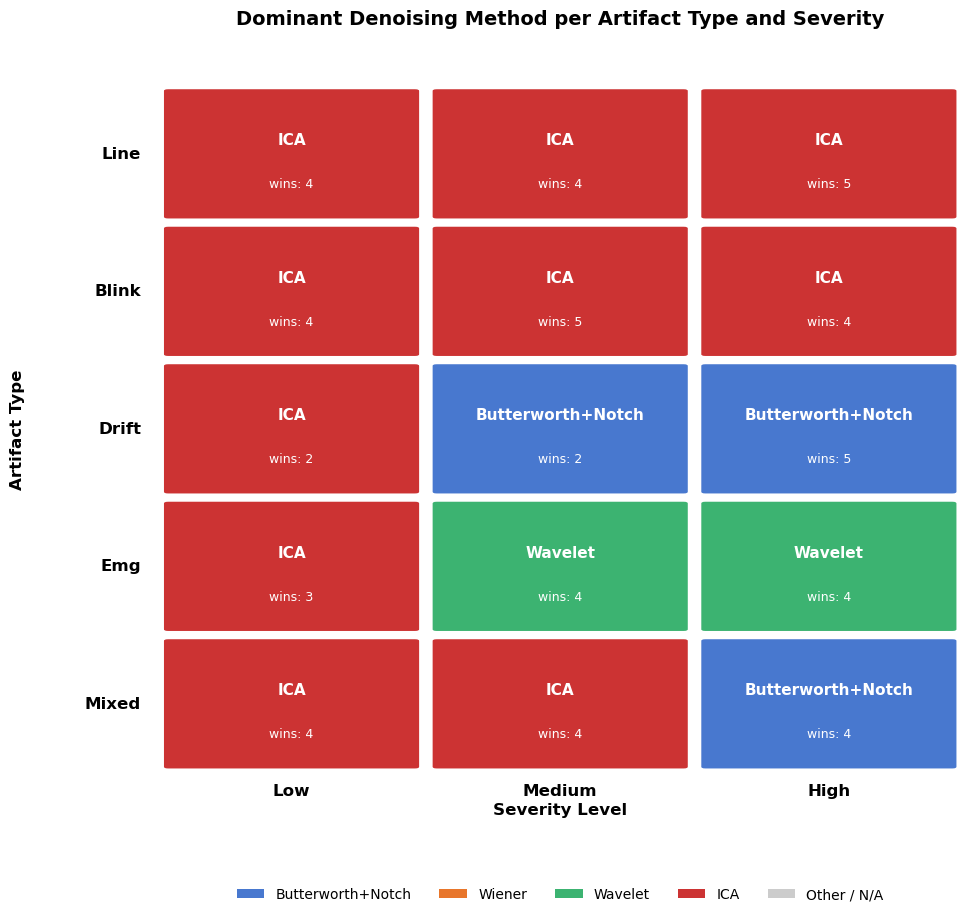

Saved: winner_heatmap.pdf


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ARTIFACT_ORDER = ["line", "blink", "drift", "emg", "mixed"]
SEVERITY_ORDER = ["low", "medium", "high"]
METHOD_COLORS = {
    "Butterworth+Notch": "#4878CF",
    "Wiener":            "#E8762B",
    "Wavelet":           "#3CB371",
    "ICA":               "#CC3333",
}
FALLBACK_COLOR = "#CCCCCC"

n_rows = len(ARTIFACT_ORDER)
n_cols = len(SEVERITY_ORDER)

cell_w = 2.8
cell_h = 1.6
fig_w = n_cols * cell_w + 2.0
fig_h = n_rows * cell_h + 2.0

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_xlim(0, n_cols)
ax.set_ylim(-0.3, n_rows + 0.3)
ax.axis("off")

for r, artifact in enumerate(ARTIFACT_ORDER):
    for c, severity in enumerate(SEVERITY_ORDER):
        subset = winner_counts[
            (winner_counts["artifact_type"] == artifact) &
            (winner_counts["severity"] == severity)
        ]
        if len(subset) == 0:
            dominant_method = "N/A"
            win_count_val = 0
        else:
            top_row = subset.sort_values("win_count", ascending=False).iloc[0]
            dominant_method = top_row["method"]
            win_count_val = int(top_row["win_count"])

        color = METHOD_COLORS.get(dominant_method, FALLBACK_COLOR)
        y = n_rows - 1 - r

        rect = mpatches.FancyBboxPatch(
            (c + 0.04, y + 0.04), 0.92, 0.92,
            boxstyle="round,pad=0.02",
            facecolor=color, edgecolor="white", linewidth=2.0,
            transform=ax.transData, clip_on=False
        )
        ax.add_patch(rect)
        ax.text(
            c + 0.5, y + 0.60, dominant_method,
            ha="center", va="center", color="white",
            fontsize=11, fontweight="bold"
        )
        ax.text(
            c + 0.5, y + 0.28, f"wins: {win_count_val}",
            ha="center", va="center", color="white", fontsize=9
        )

# Severity labels (bottom)
for c, sev in enumerate(SEVERITY_ORDER):
    ax.text(c + 0.5, -0.08, sev.capitalize(),
            ha="center", va="top", fontsize=12, fontweight="bold")

# Severity axis label
ax.text(n_cols / 2, -0.22, "Severity Level",
        ha="center", va="top", fontsize=12, fontweight="bold")

# Artifact type labels (left)
for r, artifact in enumerate(ARTIFACT_ORDER):
    y = n_rows - 1 - r
    ax.text(-0.06, y + 0.5, artifact.capitalize(),
            ha="right", va="center", fontsize=12, fontweight="bold")

# Artifact axis label
ax.text(-0.52, n_rows / 2, "Artifact Type",
        ha="center", va="center", fontsize=12, fontweight="bold",
        rotation=90)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=color, label=method)
    for method, color in METHOD_COLORS.items()
]
legend_handles.append(mpatches.Patch(facecolor=FALLBACK_COLOR, label="Other / N/A"))
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=10
)

ax.set_title(
    "Dominant Denoising Method per Artifact Type and Severity",
    fontsize=14, fontweight="bold", pad=14
)

plt.savefig("winner_heatmap.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: winner_heatmap.pdf")

## Section 9: Results — SNR Improvement vs Severity
The line plots below show how mean SNR improvement changes as artifact severity increases from low to medium to high. Key findings:
- For line noise and blink artifacts, ICA's SNR improvement increases with severity — the stronger the artifact, the better ICA performs relative to other methods. This is because ICA's source separation becomes more reliable when the artifact dominates a component clearly
- For drift artifacts, Butterworth+Notch improves with severity while ICA stays flat — filtering is increasingly effective as the slow drift grows larger
- For EMG artifacts, all methods show negative SNR improvement meaning they degrade the signal — EMG overlaps with real brain activity in the 20-40 Hz range making it the hardest artifact type for all methods
- Error bars show std across 5 subjects — ICA has larger variance than filtering methods, consistent with ICA being more sensitive to signal quality and segment length

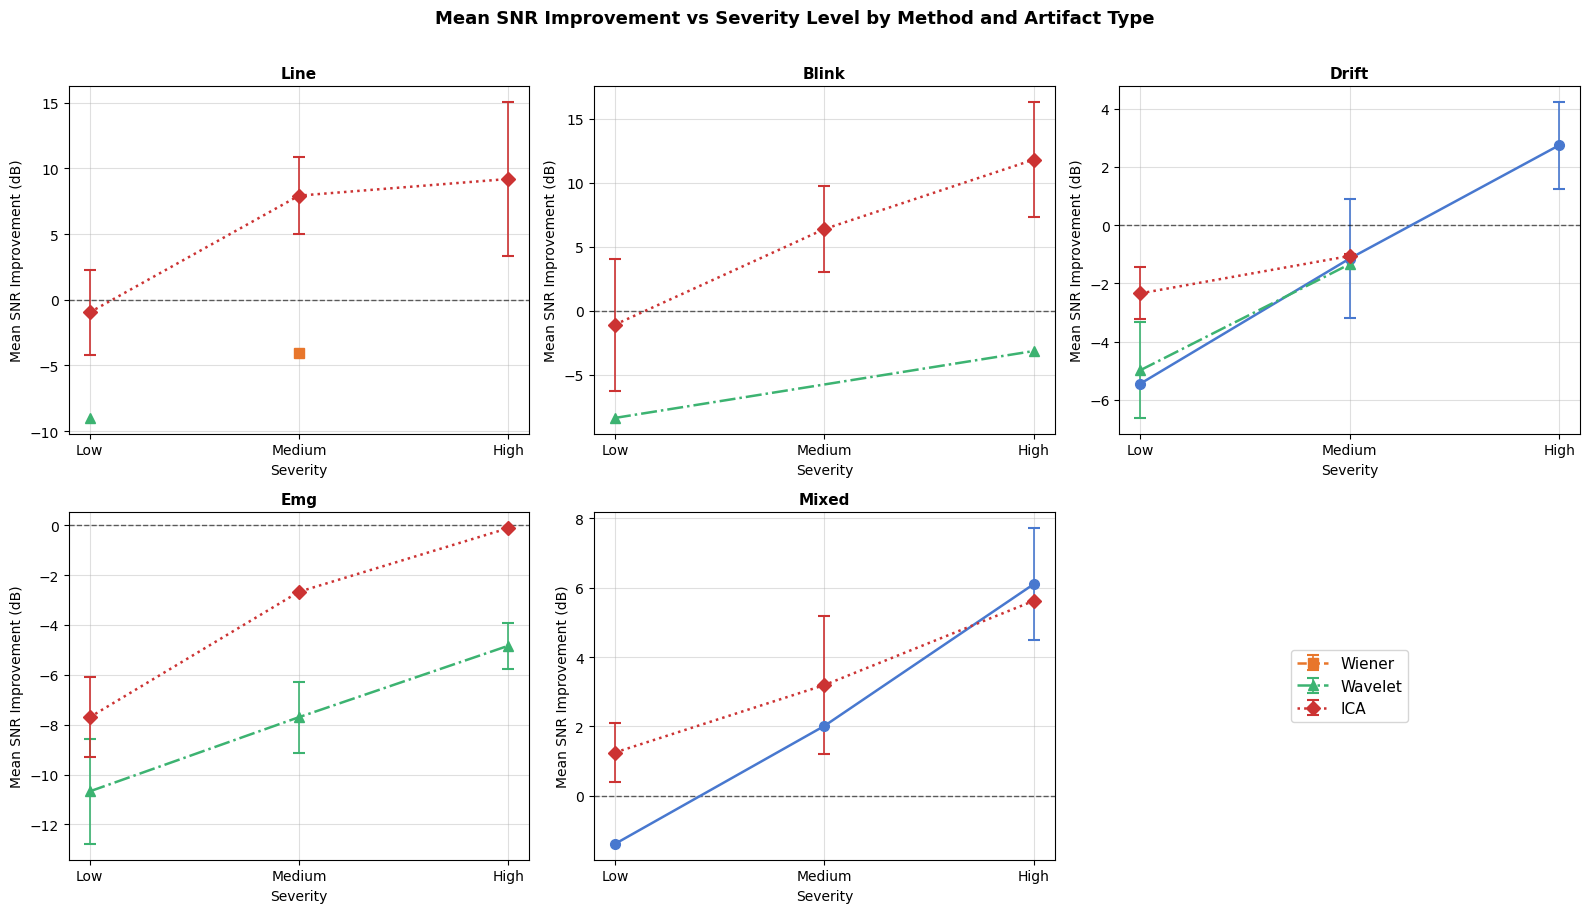

Saved: snr_improvement_by_severity.pdf


In [4]:
# Cell 2: SNR improvement vs severity — line plots per artifact type

import matplotlib.pyplot as plt
import numpy as np

ARTIFACT_ORDER = ["line", "blink", "drift", "emg", "mixed"]
SEVERITY_ORDER = ["low", "medium", "high"]

METHOD_COLORS = {
    "Butterworth+Notch": "#4878CF",
    "Wiener":            "#E8762B",
    "Wavelet":           "#3CB371",
    "ICA":               "#CC3333",
}

METHOD_STYLES = {
    "Butterworth+Notch": {"marker": "o", "linestyle": "-"},
    "Wiener":            {"marker": "s", "linestyle": "--"},
    "Wavelet":           {"marker": "^", "linestyle": "-."},
    "ICA":               {"marker": "D", "linestyle": ":"},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes_flat = axes.flatten()

for ax_idx, artifact in enumerate(ARTIFACT_ORDER):
    ax = axes_flat[ax_idx]
    subset = multi_subject_summary[multi_subject_summary["artifact_type"] == artifact].copy()
    sev_order_map = {"low": 0, "medium": 1, "high": 2}
    subset["_sev_ord"] = subset["severity"].map(sev_order_map)
    subset = subset.sort_values("_sev_ord")

    for method, color in METHOD_COLORS.items():
        mdata = subset[subset["method"] == method]
        if mdata.empty:
            continue
        x_pos = mdata["_sev_ord"].values
        y_mean = mdata["mean_snr_improvement_db"].values
        y_std  = mdata["std_snr_improvement_db"].values
        style  = METHOD_STYLES[method]
        ax.errorbar(
            x_pos, y_mean, yerr=y_std,
            color=color, label=method,
            marker=style["marker"], linestyle=style["linestyle"],
            linewidth=1.8, markersize=7, capsize=4, capthick=1.5,
            elinewidth=1.2
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Low", "Medium", "High"])
    ax.set_xlabel("Severity", fontsize=10)
    ax.set_ylabel("Mean SNR Improvement (dB)", fontsize=10)
    ax.set_title(artifact.capitalize(), fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.4)

# Hide unused 6th subplot
axes_flat[5].set_visible(False)

# Shared legend in the 6th subplot area
handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[5].set_visible(True)
axes_flat[5].axis("off")
axes_flat[5].legend(handles, labels, loc="center", fontsize=11, frameon=True)

fig.suptitle(
    "Mean SNR Improvement vs Severity Level by Method and Artifact Type",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("snr_improvement_by_severity.pdf", bbox_inches="tight")
plt.show()
print("Saved: snr_improvement_by_severity.pdf")


## Section 10: Results — Band Power Preservation
The bar chart below shows mean relative band power error per method averaged across all artifact types and severities. Lower bars indicate better preservation of EEG frequency content. Key findings:
- ICA achieves the lowest error across all four bands, confirming it best preserves the neural frequency content that EEG analysis relies on
- Butterworth+Notch performs well on theta, alpha, and beta but has elevated delta error — this is expected since the 1 Hz highpass cutoff attenuates slow delta activity (0.5-4 Hz)
- Wavelet has moderate errors across bands due to over-thresholding — the universal threshold is conservative and removes some real signal along with noise
- Wiener filter has very large alpha and especially beta band errors, suggesting it distorts the spectral content significantly despite reasonable time-domain metrics

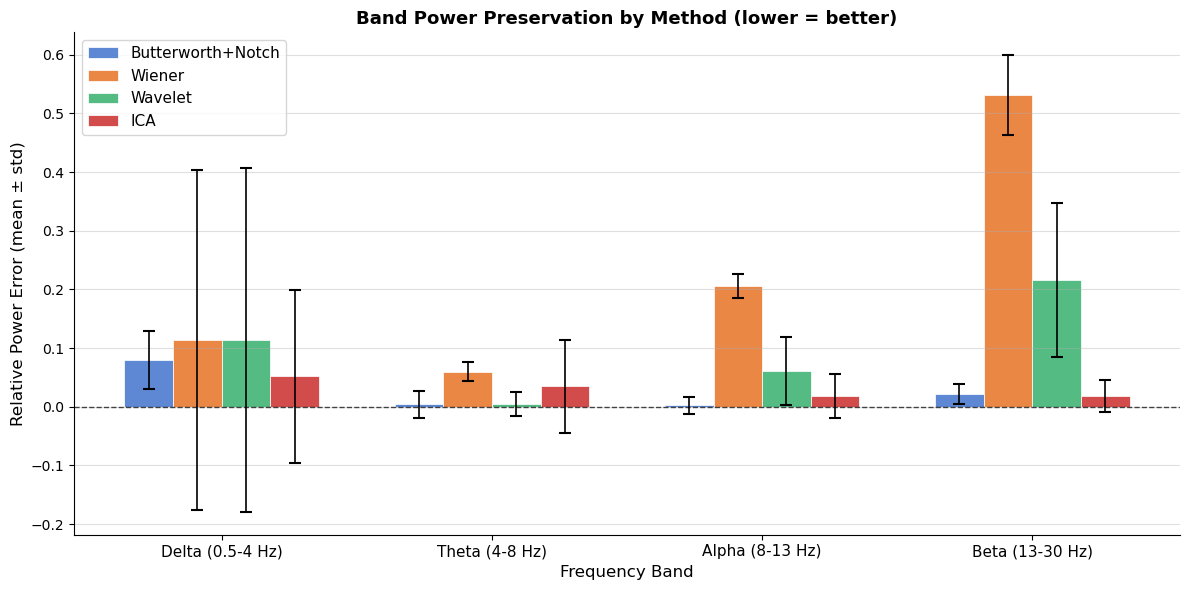

Saved: band_power_error_by_method.pdf


In [5]:
# Cell 3: Band power preservation — grouped bar chart by method

import matplotlib.pyplot as plt
import numpy as np

METHOD_COLORS = {
    "Butterworth+Notch": "#4878CF",
    "Wiener":            "#E8762B",
    "Wavelet":           "#3CB371",
    "ICA":               "#CC3333",
}

BAND_COLS   = ["delta_rel_error", "theta_rel_error", "alpha_rel_error", "beta_rel_error"]
BAND_LABELS = ["Delta (0.5-4 Hz)", "Theta (4-8 Hz)", "Alpha (8-13 Hz)", "Beta (13-30 Hz)"]

methods = [m for m in METHOD_COLORS if m in all_subject_best_df["method"].unique()]
n_bands   = len(BAND_COLS)
n_methods = len(methods)
x = np.arange(n_bands)
total_width = 0.72
bar_width   = total_width / n_methods
offsets     = np.linspace(-(total_width - bar_width) / 2,
                           (total_width - bar_width) / 2,
                           n_methods)

fig, ax = plt.subplots(figsize=(12, 6))

for off, method in zip(offsets, methods):
    mdata = all_subject_best_df[all_subject_best_df["method"] == method]
    means = [mdata[col].mean() for col in BAND_COLS]
    stds  = [mdata[col].std()  for col in BAND_COLS]
    ax.bar(
        x + off, means, bar_width,
        yerr=stds, capsize=4,
        color=METHOD_COLORS[method], label=method,
        error_kw={"elinewidth": 1.2, "capthick": 1.5},
        alpha=0.88, edgecolor="white", linewidth=0.6
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(BAND_LABELS, fontsize=11)
ax.set_xlabel("Frequency Band", fontsize=12)
ax.set_ylabel("Relative Power Error (mean ± std)", fontsize=12)
ax.set_title("Band Power Preservation by Method (lower = better)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, frameon=True)
ax.grid(True, axis="y", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("band_power_error_by_method.pdf", bbox_inches="tight")
plt.show()
print("Saved: band_power_error_by_method.pdf")


Plots Saved to CSV

In [31]:
# This block saves the multi-subject results tables for later plotting/reporting.

all_subject_results_df.to_csv("all_subject_results_df.csv", index=False)
all_subject_best_df.to_csv("all_subject_best_df.csv", index=False)
multi_subject_best_table.to_csv("multi_subject_best_table.csv", index=False)
multi_subject_summary.to_csv("multi_subject_summary.csv", index=False)
winner_counts.to_csv("winner_counts.csv", index=False)

print("Saved CSV files.")

Saved CSV files.


In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plot_dir = Path("saved_plots")
plot_dir.mkdir(exist_ok=True)

severity_order = {"low": 0, "medium": 1, "high": 2}
method_order = ["Butterworth+Notch", "Wiener", "Wavelet", "ICA"]

def savefig(name):
    plt.tight_layout()
    plt.savefig(plot_dir / name, dpi=300, bbox_inches="tight")
    plt.close()

def safe_method_name(s):
    return str(s).replace("+", "plus").replace(" ", "_")

def apply_best_method_from_row(row, noisy_data, artifact_data, raw_clean_ref, sfreq):
    method = row["method"]

    if method == "Butterworth+Notch":
        return butterworth_notch_denoise(
            noisy_data,
            sfreq=sfreq,
            l_freq=float(row["l_freq"]),
            h_freq=float(row["h_freq"]),
            notch_freq=60.0,
            q=float(row["q"]),
            order=int(row["order"])
        )

    elif method == "Wiener":
        return wiener_denoise(
            noisy_data,
            mysize=int(row["mysize"])
        )

    elif method == "Wavelet":
        return wavelet_denoise(
            noisy_data,
            wavelet=str(row["wavelet"]),
            level=int(row["level"]),
            threshold_scale=float(row["threshold_scale"]),
            mode=str(row["mode"])
        )

    elif method == "ICA":
        raw_noisy_local = mne.io.RawArray(noisy_data.copy(), raw_clean_ref.info.copy(), verbose=False)
        denoised, _ = ica_denoise_with_artifact_reference(
            raw_noisy=raw_noisy_local,
            artifact_data=artifact_data,
            n_components=int(row["n_components"]),
            top_k=int(row["top_k"]),
            random_state=97
        )
        return denoised

    else:
        raise ValueError(f"Unknown method: {method}")

# ------------------------------------------------------------------------------
# 1. Save summary tables as CSV as well
# ------------------------------------------------------------------------------

if "artifact_severity_summary_display" in globals():
    artifact_severity_summary_display.to_csv(plot_dir / "artifact_severity_summary_display.csv", index=False)

if "artifact_severity_summary_table" in globals():
    artifact_severity_summary_table.to_csv(plot_dir / "artifact_severity_summary_table.csv", index=False)

if "gap_table" in globals():
    gap_table.to_csv(plot_dir / "gap_table.csv", index=False)

if "multi_subject_best_table" in globals():
    multi_subject_best_table.to_csv(plot_dir / "multi_subject_best_table.csv", index=False)

if "multi_subject_summary" in globals():
    multi_subject_summary.to_csv(plot_dir / "multi_subject_summary.csv", index=False)

if "winner_counts" in globals():
    winner_counts.to_csv(plot_dir / "winner_counts.csv", index=False)

# ------------------------------------------------------------------------------
# 2. Single-subject summary plots
# ------------------------------------------------------------------------------

if "artifact_severity_summary_display" in globals():
    df = artifact_severity_summary_display.copy()
    df["severity_order"] = df["severity"].map(severity_order)
    df = df.sort_values(["artifact_type", "severity_order"])

    # Combined score by artifact/severity
    plt.figure(figsize=(14, 6))
    for artifact in sorted(df["artifact_type"].unique()):
        sub = df[df["artifact_type"] == artifact].sort_values("severity_order")
        plt.plot(sub["severity"], sub["combined_score"], marker="o", label=artifact)
    plt.title("Best Combined Score vs Severity (Single Subject)")
    plt.xlabel("Severity")
    plt.ylabel("Combined Score")
    plt.grid(True)
    plt.legend()
    savefig("single_subject_best_combined_score_vs_severity.png")

    # Best method by artifact/severity as text grid
    artifact_list = sorted(df["artifact_type"].unique())
    sev_list = ["low", "medium", "high"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")
    table_data = []
    for artifact in artifact_list:
        row_vals = [artifact]
        for sev in sev_list:
            sub = df[(df["artifact_type"] == artifact) & (df["severity"] == sev)]
            row_vals.append(sub.iloc[0]["method"] if len(sub) > 0 else "")
        table_data.append(row_vals)

    col_labels = ["artifact_type", "low", "medium", "high"]
    tbl = ax.table(cellText=table_data, colLabels=col_labels, loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.6)
    plt.title("Winning Method by Artifact and Severity (Single Subject)")
    savefig("single_subject_winning_method_table.png")

    # SNR improvement by artifact/severity
    plt.figure(figsize=(14, 6))
    for artifact in sorted(df["artifact_type"].unique()):
        sub = df[df["artifact_type"] == artifact].sort_values("severity_order")
        plt.plot(sub["severity"], sub["snr_improvement_db"], marker="o", label=artifact)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Best SNR Improvement vs Severity (Single Subject)")
    plt.xlabel("Severity")
    plt.ylabel("SNR Improvement (dB)")
    plt.grid(True)
    plt.legend()
    savefig("single_subject_best_snr_improvement_vs_severity.png")

# ------------------------------------------------------------------------------
# 3. Winner-gap plots
# ------------------------------------------------------------------------------

if "gap_table" in globals() and len(gap_table) > 0:
    gap_df = gap_table.copy()
    gap_df["severity_order"] = gap_df["severity"].map(severity_order)
    gap_df = gap_df.sort_values(["artifact_type", "severity_order"])

    plt.figure(figsize=(14, 6))
    for artifact in sorted(gap_df["artifact_type"].unique()):
        sub = gap_df[gap_df["artifact_type"] == artifact].sort_values("severity_order")
        plt.plot(sub["severity"], sub["score_gap"], marker="o", label=artifact)
    plt.title("Gap Between Best Method and Runner-Up (Single Subject)")
    plt.xlabel("Severity")
    plt.ylabel("Combined Score Gap")
    plt.grid(True)
    plt.legend()
    savefig("single_subject_best_vs_runnerup_gap.png")

# ------------------------------------------------------------------------------
# 4. Waveform and PSD plots for every artifact/severity using the winning method
# ------------------------------------------------------------------------------

if "artifact_severity_summary_table" in globals():
    summary_df = artifact_severity_summary_table.copy()
    channel_name = ch_names[0]
    idx = ch_names.index(channel_name)

    for _, row in summary_df.iterrows():
        artifact_type = row["artifact_type"]
        severity = row["severity"]
        method = row["method"]

        # Fixed seed per condition for reproducible plotting
        seed_val = abs(hash((artifact_type, severity))) % (2**32)
        local_rng = np.random.default_rng(seed_val)

        noisy_data_plot, artifact_data_plot, artifact_log_plot = generate_noisy_sample_with_severity(
            clean_data=clean_data,
            sfreq=sfreq,
            ch_names=ch_names,
            rng=local_rng,
            artifact_type=artifact_type,
            severity=severity
        )

        best_output = apply_best_method_from_row(
            row=row,
            noisy_data=noisy_data_plot,
            artifact_data=artifact_data_plot,
            raw_clean_ref=raw_clean,
            sfreq=sfreq
        )

        # Waveform plot
        plt.figure(figsize=(14, 6))
        plt.plot(times, clean_data[idx], label="clean", linewidth=2)
        plt.plot(times, noisy_data_plot[idx], label=f"noisy ({artifact_type}, {severity})", alpha=0.7)
        plt.plot(times, best_output[idx], label=f"best denoised ({method})", alpha=0.9)
        plt.title(f"Waveform: {artifact_type} | {severity} | best = {method} | channel = {channel_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()
        savefig(f"waveform_{artifact_type}_{severity}_{safe_method_name(method)}_{channel_name}.png")

        # PSD plot
        f_clean, pxx_clean = signal.welch(clean_data[idx], fs=sfreq, nperseg=min(512, clean_data.shape[1]))
        f_noisy, pxx_noisy = signal.welch(noisy_data_plot[idx], fs=sfreq, nperseg=min(512, noisy_data_plot.shape[1]))
        f_best, pxx_best = signal.welch(best_output[idx], fs=sfreq, nperseg=min(512, best_output.shape[1]))

        plt.figure(figsize=(12, 5))
        plt.semilogy(f_clean, pxx_clean, label="clean", linewidth=2)
        plt.semilogy(f_noisy, pxx_noisy, label="noisy", alpha=0.7)
        plt.semilogy(f_best, pxx_best, label=f"best denoised ({method})", alpha=0.9)
        plt.xlim(0, 80)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD")
        plt.title(f"PSD: {artifact_type} | {severity} | best = {method} | channel = {channel_name}")
        plt.grid(True)
        plt.legend()
        savefig(f"psd_{artifact_type}_{severity}_{safe_method_name(method)}_{channel_name}.png")

# ------------------------------------------------------------------------------
# 5. Multi-subject plots
# ------------------------------------------------------------------------------

if "multi_subject_summary" in globals():
    ms = multi_subject_summary.copy()
    ms["severity_order"] = ms["severity"].map(severity_order)
    ms["method_order"] = ms["method"].map({m: i for i, m in enumerate(method_order)})

    # Best mean combined score per artifact/severity
    best_ms_rows = []
    for (artifact_type, severity), group in ms.groupby(["artifact_type", "severity"]):
        best_ms_rows.append(group.sort_values("mean_combined_score", ascending=False).iloc[0])
    best_ms_df = pd.DataFrame(best_ms_rows).sort_values(["artifact_type", "severity_order"])

    plt.figure(figsize=(14, 6))
    for artifact in sorted(best_ms_df["artifact_type"].unique()):
        sub = best_ms_df[best_ms_df["artifact_type"] == artifact].sort_values("severity_order")
        plt.plot(sub["severity"], sub["mean_combined_score"], marker="o", label=artifact)
    plt.title("Best Mean Combined Score vs Severity (Multi-Subject)")
    plt.xlabel("Severity")
    plt.ylabel("Mean Combined Score")
    plt.grid(True)
    plt.legend()
    savefig("multi_subject_best_mean_combined_score_vs_severity.png")

    # Best mean SNR improvement per artifact/severity
    plt.figure(figsize=(14, 6))
    for artifact in sorted(best_ms_df["artifact_type"].unique()):
        sub = best_ms_df[best_ms_df["artifact_type"] == artifact].sort_values("severity_order")
        plt.plot(sub["severity"], sub["mean_snr_improvement_db"], marker="o", label=artifact)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Best Mean SNR Improvement vs Severity (Multi-Subject)")
    plt.xlabel("Severity")
    plt.ylabel("Mean SNR Improvement (dB)")
    plt.grid(True)
    plt.legend()
    savefig("multi_subject_best_mean_snr_improvement_vs_severity.png")

    # Per-artifact bar charts comparing methods
    for artifact in sorted(ms["artifact_type"].unique()):
        sub = ms[ms["artifact_type"] == artifact].copy()
        for metric, fname, ylabel in [
            ("mean_combined_score", f"multi_subject_{artifact}_mean_combined_score.png", "Mean Combined Score"),
            ("mean_snr_improvement_db", f"multi_subject_{artifact}_mean_snr_improvement.png", "Mean SNR Improvement (dB)"),
            ("mean_band_rel_error", f"multi_subject_{artifact}_mean_band_error.png", "Mean Band Relative Error"),
        ]:
            plt.figure(figsize=(10, 5))
            width = 0.2
            x = np.arange(3)
            sev_list = ["low", "medium", "high"]

            methods_present = [m for m in method_order if m in sub["method"].unique()]
            offsets = np.linspace(-width*(len(methods_present)-1)/2, width*(len(methods_present)-1)/2, len(methods_present))

            for off, method in zip(offsets, methods_present):
                vals = []
                for sev in sev_list:
                    g = sub[(sub["severity"] == sev) & (sub["method"] == method)]
                    vals.append(g.iloc[0][metric] if len(g) > 0 else np.nan)
                plt.bar(x + off, vals, width=width, label=method)

            plt.xticks(x, sev_list)
            plt.title(f"{artifact}: {ylabel} by Method")
            plt.xlabel("Severity")
            plt.ylabel(ylabel)
            plt.grid(True, axis="y")
            plt.legend()
            savefig(fname)

# ------------------------------------------------------------------------------
# 6. Winner-count plots
# ------------------------------------------------------------------------------

if "winner_counts" in globals():
    wc = winner_counts.copy()
    wc["severity_order"] = wc["severity"].map(severity_order)

    for artifact in sorted(wc["artifact_type"].unique()):
        sub = wc[wc["artifact_type"] == artifact].copy()

        plt.figure(figsize=(10, 5))
        width = 0.2
        x = np.arange(3)
        sev_list = ["low", "medium", "high"]

        methods_present = [m for m in method_order if m in sub["method"].unique()]
        offsets = np.linspace(-width*(len(methods_present)-1)/2, width*(len(methods_present)-1)/2, len(methods_present))

        for off, method in zip(offsets, methods_present):
            vals = []
            for sev in sev_list:
                g = sub[(sub["severity"] == sev) & (sub["method"] == method)]
                vals.append(g.iloc[0]["win_count"] if len(g) > 0 else 0)
            plt.bar(x + off, vals, width=width, label=method)

        plt.xticks(x, sev_list)
        plt.title(f"{artifact}: Winner Count by Method Across Subjects")
        plt.xlabel("Severity")
        plt.ylabel("Win Count")
        plt.grid(True, axis="y")
        plt.legend()
        savefig(f"winner_counts_{artifact}.png")

print(f"Saved plots and tables to: {plot_dir.resolve()}")

Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out

## Section 11: Discussion and Conclusions

### Summary of Findings
No single method is universally best — performance depends on artifact type and severity. ICA achieves the highest overall SNR improvement and best band power preservation, making it the recommended general-purpose method. However, Butterworth+Notch is more reliable for baseline drift and requires no parameter tuning, making it a practical choice when drift is the primary concern. Wavelet denoising performs well on EMG artifacts at higher severities but its universal threshold needs tuning to avoid over-smoothing. Wiener filtering underperforms across all conditions and is not recommended for EEG denoising.

### Limitations
The pseudo-clean reference signal is derived from filtered EEG rather than truly clean simulated data, meaning our ground truth contains residual real-world artifacts. Results are based on 20-second segments from 5 subjects, which limits the statistical power. ICA performance is known to improve with longer recordings and more channels.

### Future Work
- Implement adaptive per-subband wavelet thresholding to address the over-thresholding problem identified in our results
- Evaluate hybrid pipelines combining ICA for blink removal followed by wavelet denoising for residual EMG
- Extend evaluation to more subjects and longer recording segments
- Compare against modern deep learning denoising approaches

### Contributions
Rohith Koneti and Kishant Mohan contributed equally. Kishant implemented the noise generation pipeline, artifact injection framework, and multi-subject experiment infrastructure. Rohith implemented the denoising methods, evaluation metrics, parameter sweep framework, and visualization.